In [2]:
!pip install "scikit-learn<1.6.0" scikeras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Times New Roman setup -- ttf-mscorefonts-installer is unreliable (its
# post-install script downloads and checksums old .exe cabinets from
# SourceForge, which fails constantly), so the actual font file is
# pulled directly and registered with matplotlib instead.
!wget -q -O "TimesNewRoman.ttf" "https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf"

import matplotlib
import matplotlib.font_manager as font_manager
import shutil

shutil.rmtree(matplotlib.get_cachedir(), ignore_errors=True)
font_manager.fontManager.addfont("TimesNewRoman.ttf")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 71.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
# Global Plot Formatting

plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600

plt.rcParams['font.family'] = 'Times New Roman'

plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15

plt.rcParams['legend.fontsize'] = 15

sns.set_style("whitegrid")
sns.set_context("notebook")

label_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': 'Times New Roman'
}

title_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': 'Times New Roman'
}

legend_style = {
    'family': 'Times New Roman',
    'weight': 'bold',
    'size': 15
}

def format_axis_ticks(current_axis):

    for tick_label in (
        current_axis.get_xticklabels()
        + current_axis.get_yticklabels()
    ):
        tick_label.set_fontweight('bold')
        tick_label.set_fontname('Times New Roman')

def format_legend_text(current_legend):

    if current_legend is not None:

        for legend_entry in current_legend.get_texts():
            legend_entry.set_fontweight('bold')
            legend_entry.set_fontname('Times New Roman')

        legend_title = current_legend.get_title()
        legend_title.set_fontweight('bold')
        legend_title.set_fontname('Times New Roman')

In [ ]:
# Task 1 : Dataset Exploration
from tensorflow.keras.datasets import fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("Training Images Shape :", train_images.shape)
print("Training Labels Shape :", train_labels.shape)
print("Testing Images Shape  :", test_images.shape)
print("Testing Labels Shape  :", test_labels.shape)

print("\nPixel value range :", train_images.min(), "to", train_images.max())

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)

Pixel value range : 0 to 255


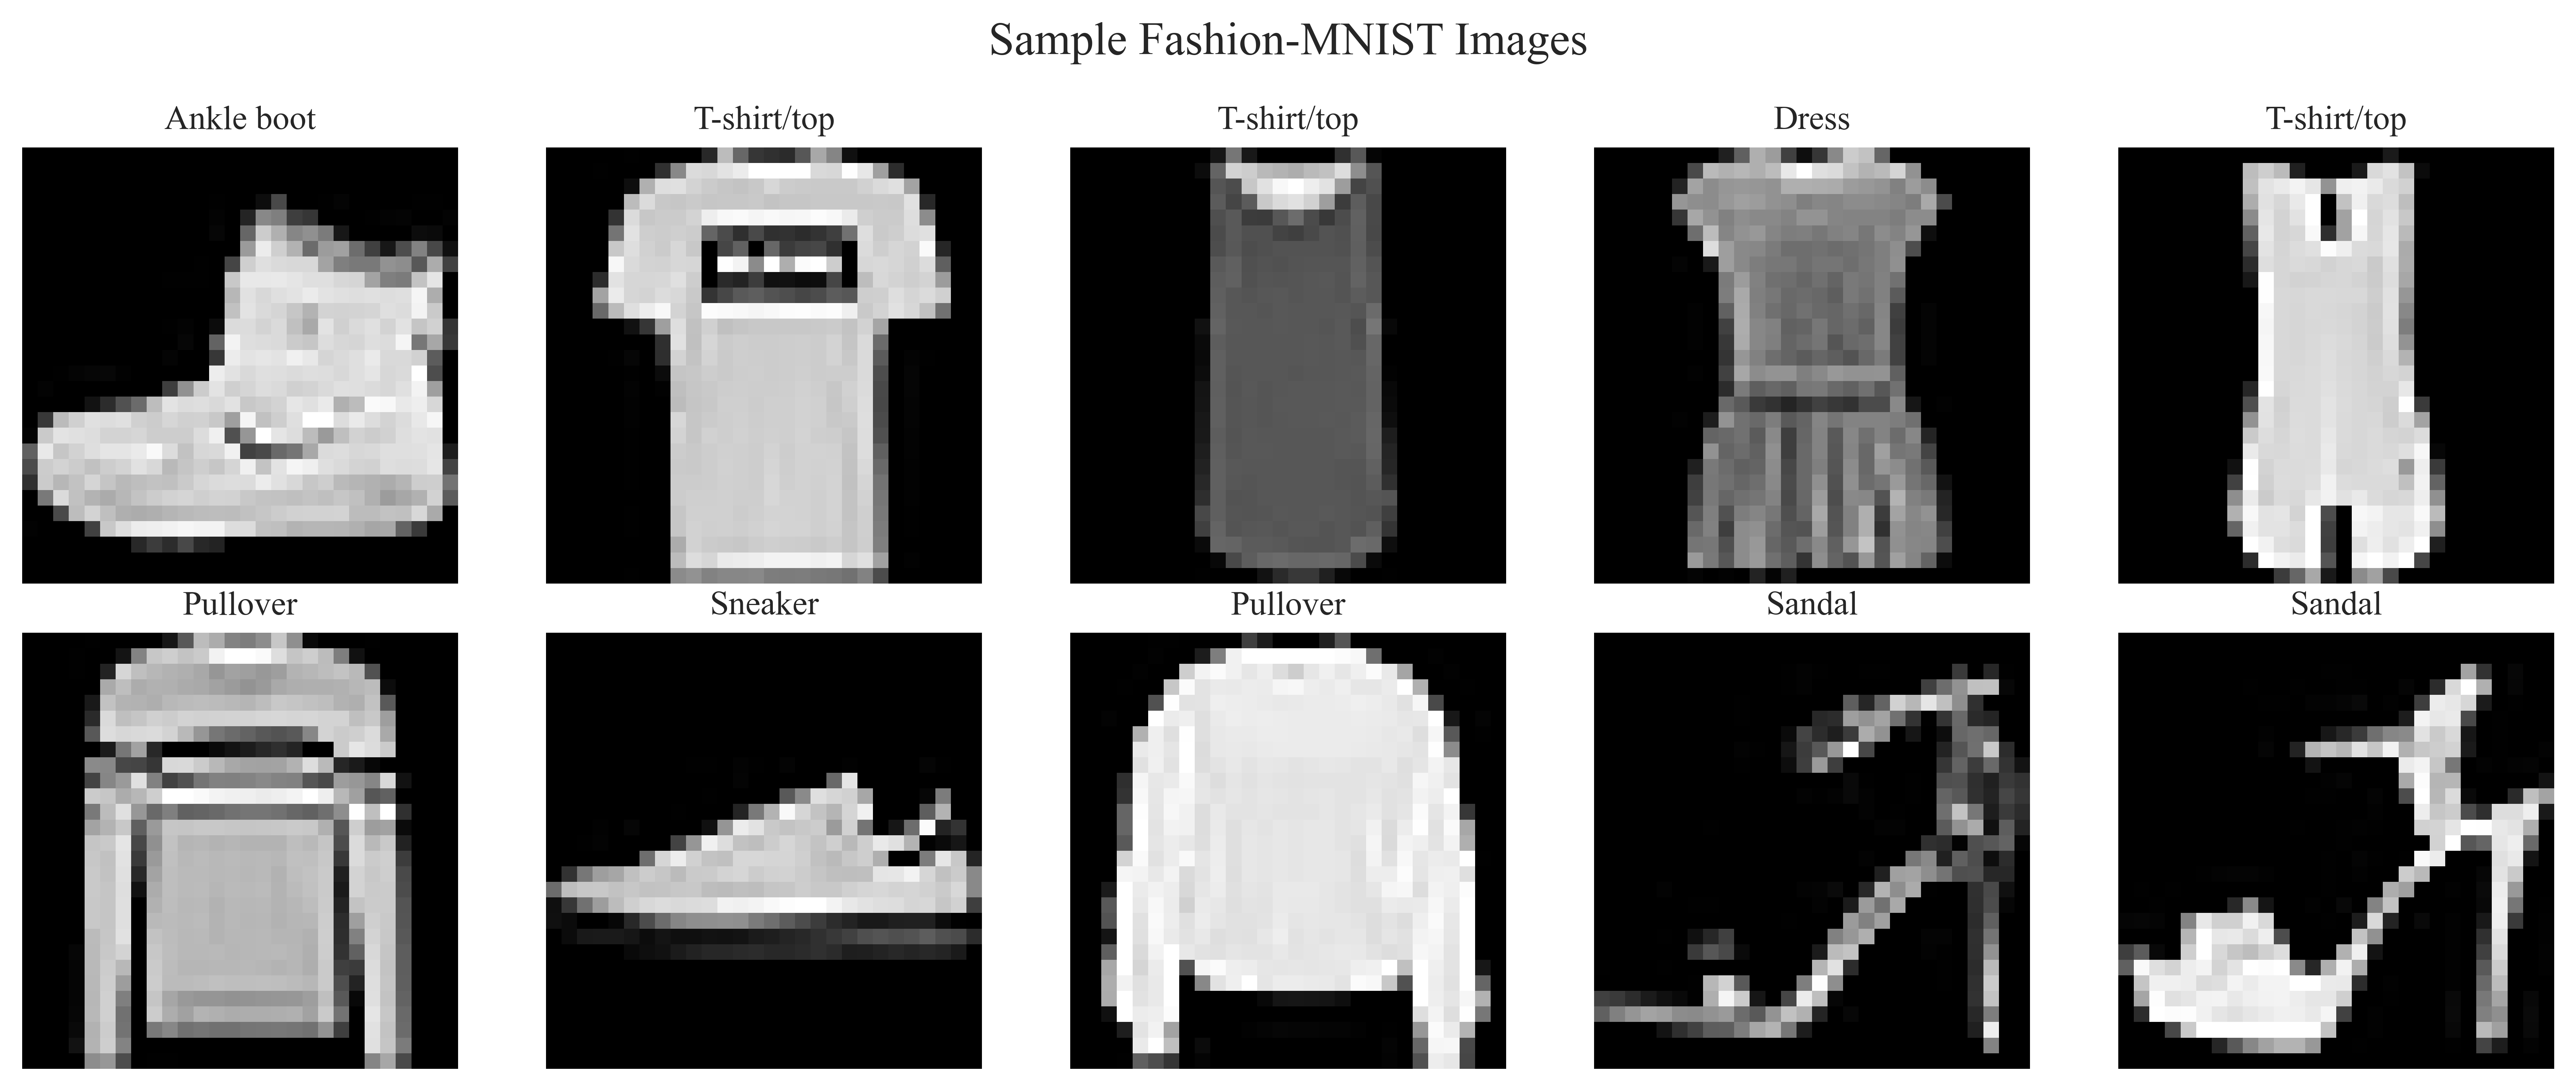

In [ ]:
# Sample Images
sample_figure, sample_axes = plt.subplots(2, 5, figsize=(12, 5))

for current_axis, image_index in zip(sample_axes.flatten(), range(10)):

    current_axis.imshow(train_images[image_index], cmap='gray')
    current_axis.set_title(
        class_names[train_labels[image_index]],
        fontsize=11,
        fontweight='bold',
        fontname='Times New Roman'
    )
    current_axis.axis('off')

sample_figure.suptitle(
    "Sample Fashion-MNIST Images",
    fontsize=15,
    fontweight='bold',
    fontname='Times New Roman'
)

plt.tight_layout()

plt.savefig(
    "sample_images.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

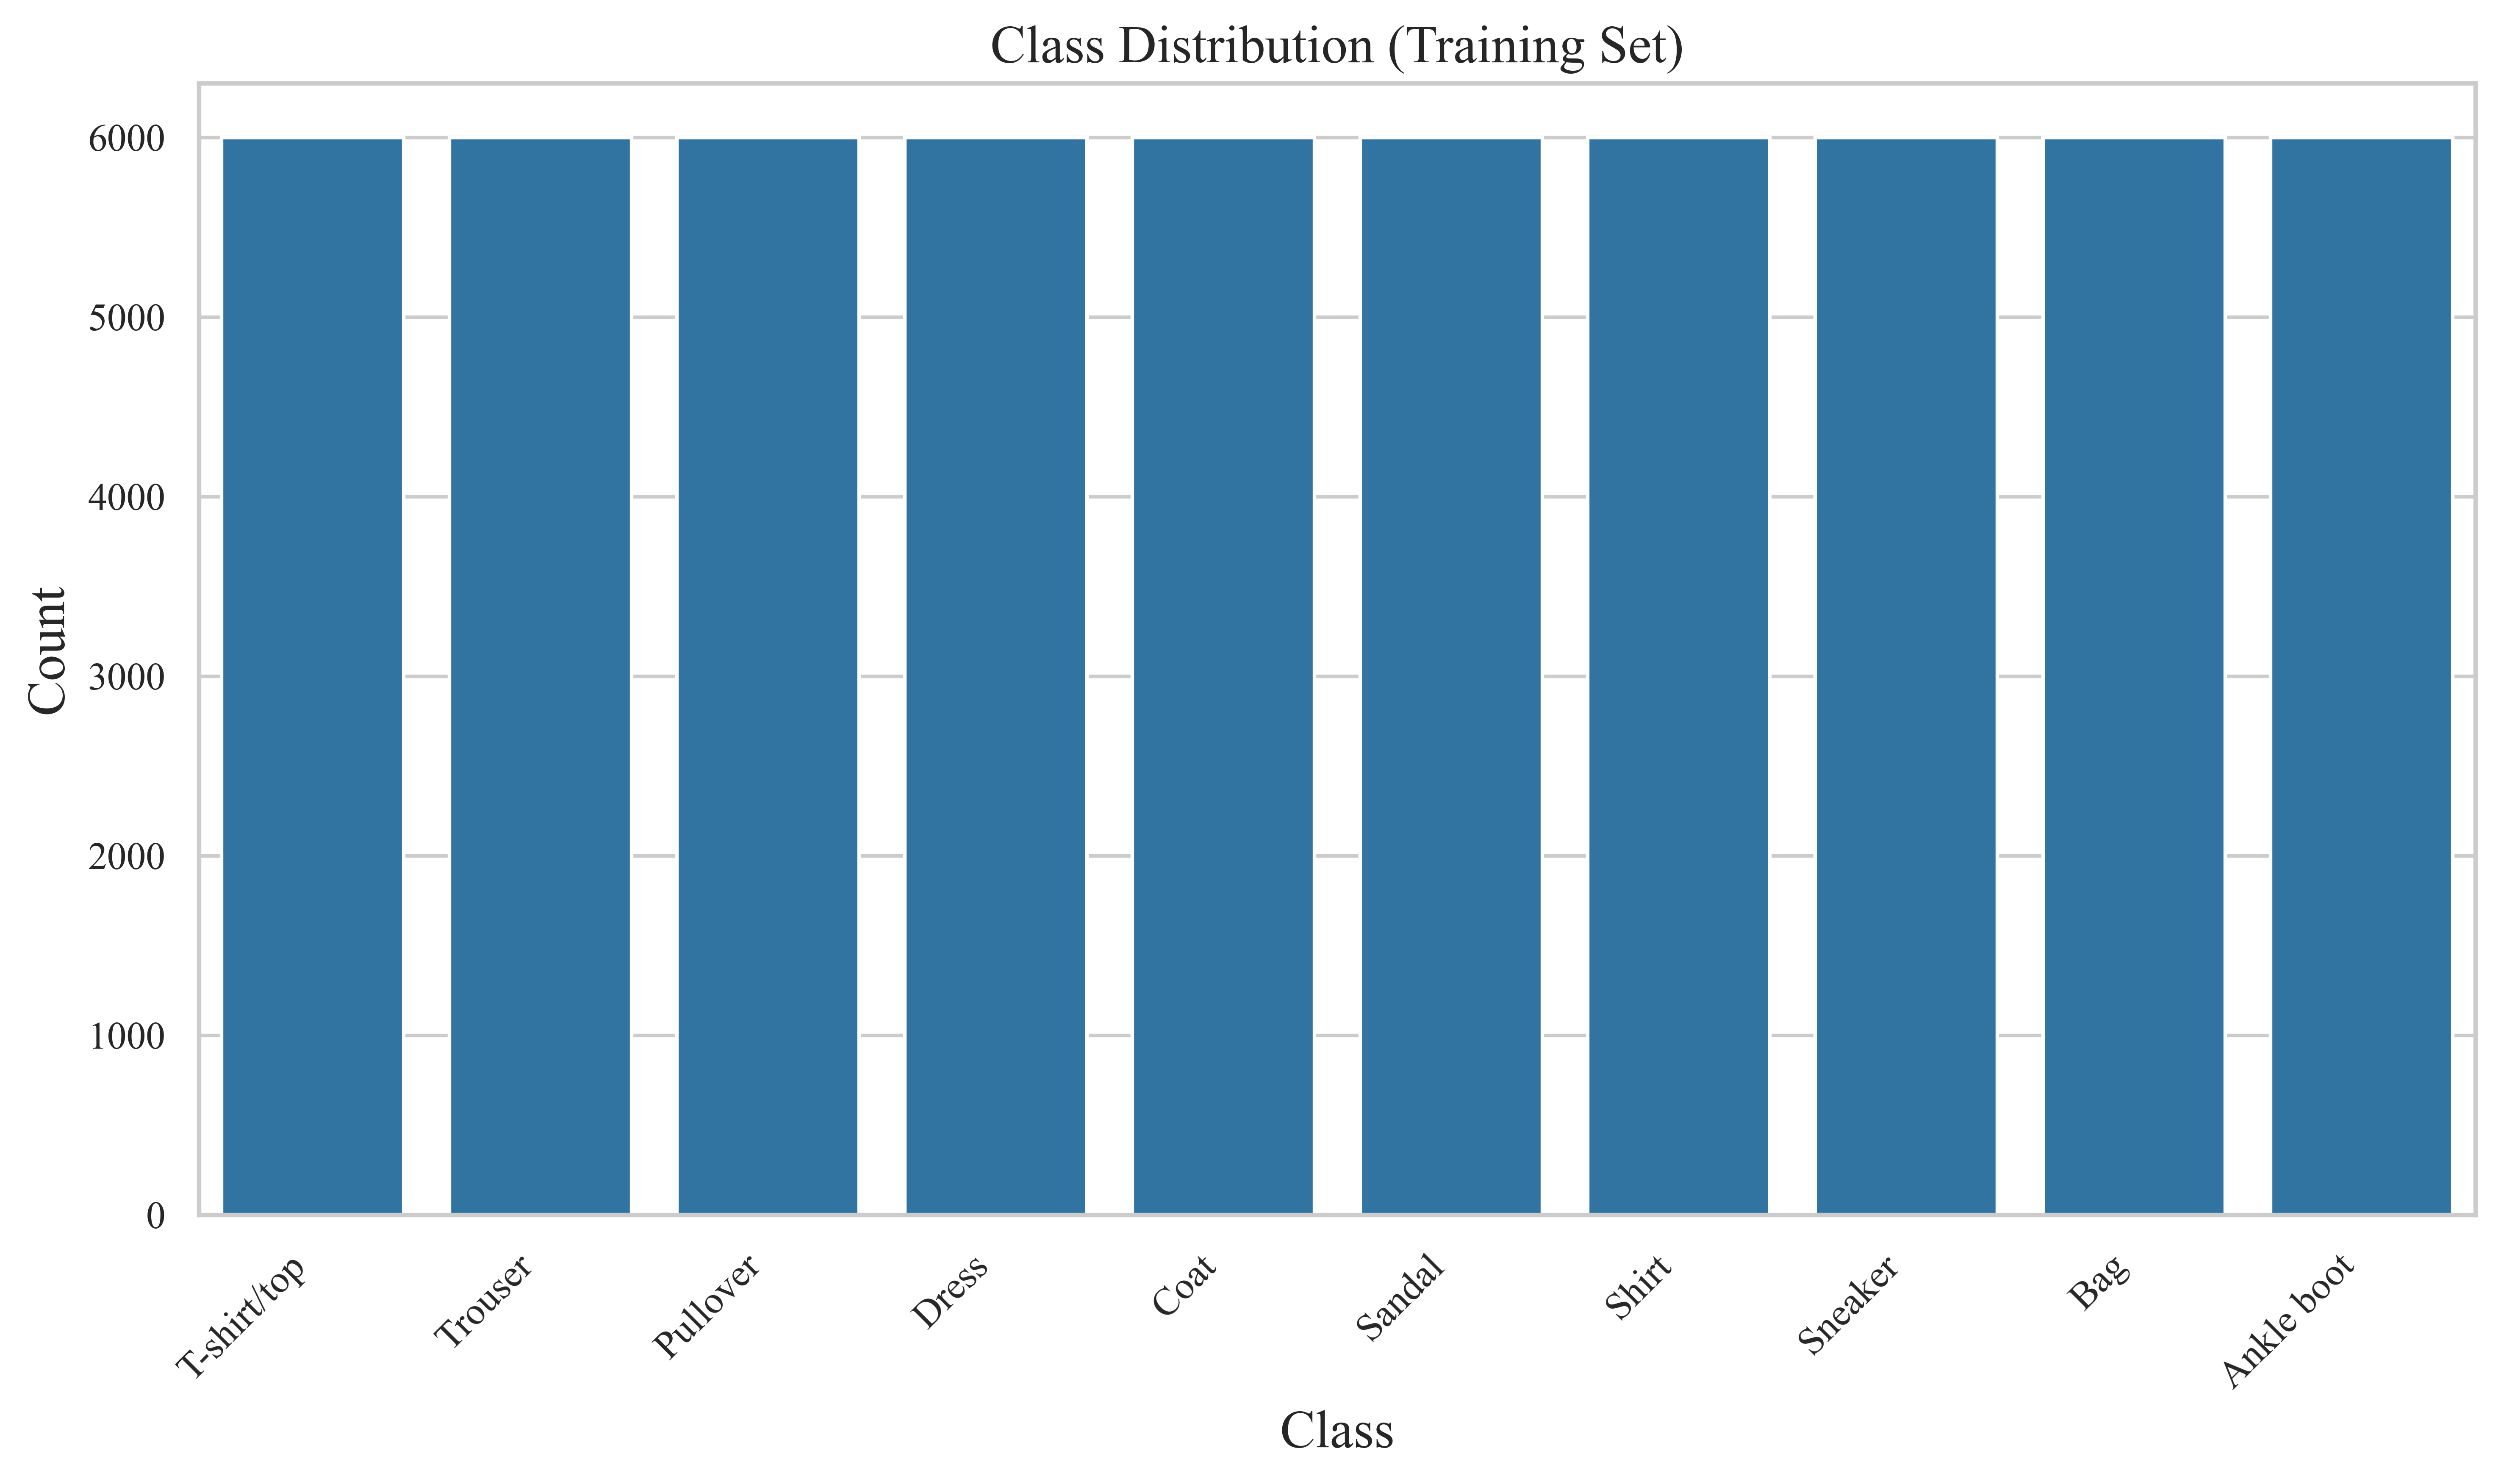

In [ ]:
# Class Distribution
class_distribution_frame = pd.DataFrame({
    'class_name': [class_names[label] for label in train_labels]
})

plt.figure(figsize=(10, 6))

class_dist_axis = sns.countplot(
    data=class_distribution_frame,
    x='class_name',
    order=class_names
)

class_dist_axis.set_xlabel("Class", **label_style)
class_dist_axis.set_ylabel("Count", **label_style)
class_dist_axis.set_title("Class Distribution (Training Set)", **title_style)

plt.xticks(rotation=45, ha='right')
format_axis_ticks(class_dist_axis)

plt.tight_layout()

plt.savefig(
    "class_distribution.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# Task 2 : Data Preprocessing
print("Shape before preprocessing :", train_images.shape, test_images.shape)

flattened_train_images = train_images.reshape(train_images.shape[0], -1).astype('float32')
flattened_test_images = test_images.reshape(test_images.shape[0], -1).astype('float32')

normalized_train_images = flattened_train_images / 255.0
normalized_test_images = flattened_test_images / 255.0

from tensorflow.keras.utils import to_categorical

one_hot_train_labels = to_categorical(train_labels, num_classes=10)
one_hot_test_labels = to_categorical(test_labels, num_classes=10)

print("Shape after preprocessing  :", normalized_train_images.shape, normalized_test_images.shape)
print("One-hot label shape        :", one_hot_train_labels.shape, one_hot_test_labels.shape)

Shape before preprocessing : (60000, 28, 28) (10000, 28, 28)
Shape after preprocessing  : (60000, 784) (10000, 784)
One-hot label shape        : (60000, 10) (10000, 10)


In [ ]:
# Task 3 : Model Construction

def build_baseline_mlp():
    """Fixed baseline architecture exactly as recommended in the lab manual:
    784 -> Dense(128, ReLU) -> Dense(64, ReLU) -> Dense(10, Softmax)."""

    mlp_model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ])

    mlp_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return mlp_model


def build_mlp_model(
    hidden_layers=2,
    hidden_neurons=128,
    learning_rate=0.001,
    optimizer_name='adam',
    activation_function='relu',
    dropout_rate=0.0,
    loss_function='categorical_crossentropy'
):
    """General-purpose, fully parameterized builder used for the
    hyperparameter search (Task 7) and for retraining with the best
    hyperparameters found.

    FIX: every hidden layer now gets `hidden_neurons` units. The earlier
    version of this function hardcoded the first two hidden layers to
    128 and 64 neurons regardless of what `hidden_neurons` was set to,
    which silently broke the 'Hidden Neurons' dimension of the
    hyperparameter search (it had almost no effect on the resulting
    architecture for hidden_layers=1 or 2)."""

    mlp_model = keras.Sequential()
    mlp_model.add(layers.Input(shape=(784,)))

    for _ in range(hidden_layers):

        mlp_model.add(
            layers.Dense(
                hidden_neurons,
                activation=activation_function
            )
        )

        if dropout_rate > 0.0:
            mlp_model.add(layers.Dropout(dropout_rate))

    mlp_model.add(layers.Dense(10, activation='softmax'))

    if optimizer_name == 'adam':
        chosen_optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        chosen_optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        chosen_optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)

    mlp_model.compile(
        optimizer=chosen_optimizer,
        loss=loss_function,
        metrics=['accuracy']
    )

    return mlp_model


baseline_model = build_baseline_mlp()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Task 4 : Model Training
training_history = baseline_model.fit(
    normalized_train_images,
    one_hot_train_labels,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=2
)

Epoch 1/20
1688/1688 - 16s - 9ms/step - accuracy: 0.8189 - loss: 0.5036 - val_accuracy: 0.8470 - val_loss: 0.4107
Epoch 2/20
1688/1688 - 8s - 5ms/step - accuracy: 0.8649 - loss: 0.3720 - val_accuracy: 0.8708 - val_loss: 0.3537
Epoch 3/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8769 - loss: 0.3359 - val_accuracy: 0.8692 - val_loss: 0.3492
Epoch 4/20
1688/1688 - 6s - 4ms/step - accuracy: 0.8852 - loss: 0.3122 - val_accuracy: 0.8738 - val_loss: 0.3477
Epoch 5/20
1688/1688 - 9s - 5ms/step - accuracy: 0.8907 - loss: 0.2924 - val_accuracy: 0.8813 - val_loss: 0.3264
Epoch 6/20
1688/1688 - 10s - 6ms/step - accuracy: 0.8971 - loss: 0.2781 - val_accuracy: 0.8847 - val_loss: 0.3310
Epoch 7/20
1688/1688 - 9s - 5ms/step - accuracy: 0.9006 - loss: 0.2657 - val_accuracy: 0.8790 - val_loss: 0.3466
Epoch 8/20
1688/1688 - 8s - 5ms/step - accuracy: 0.9060 - loss: 0.2543 - val_accuracy: 0.8825 - val_loss: 0.3188
Epoch 9/20
1688/1688 - 9s - 5ms/step - accuracy: 0.9085 - loss: 0.2450 - val_accuracy: 0.8822 

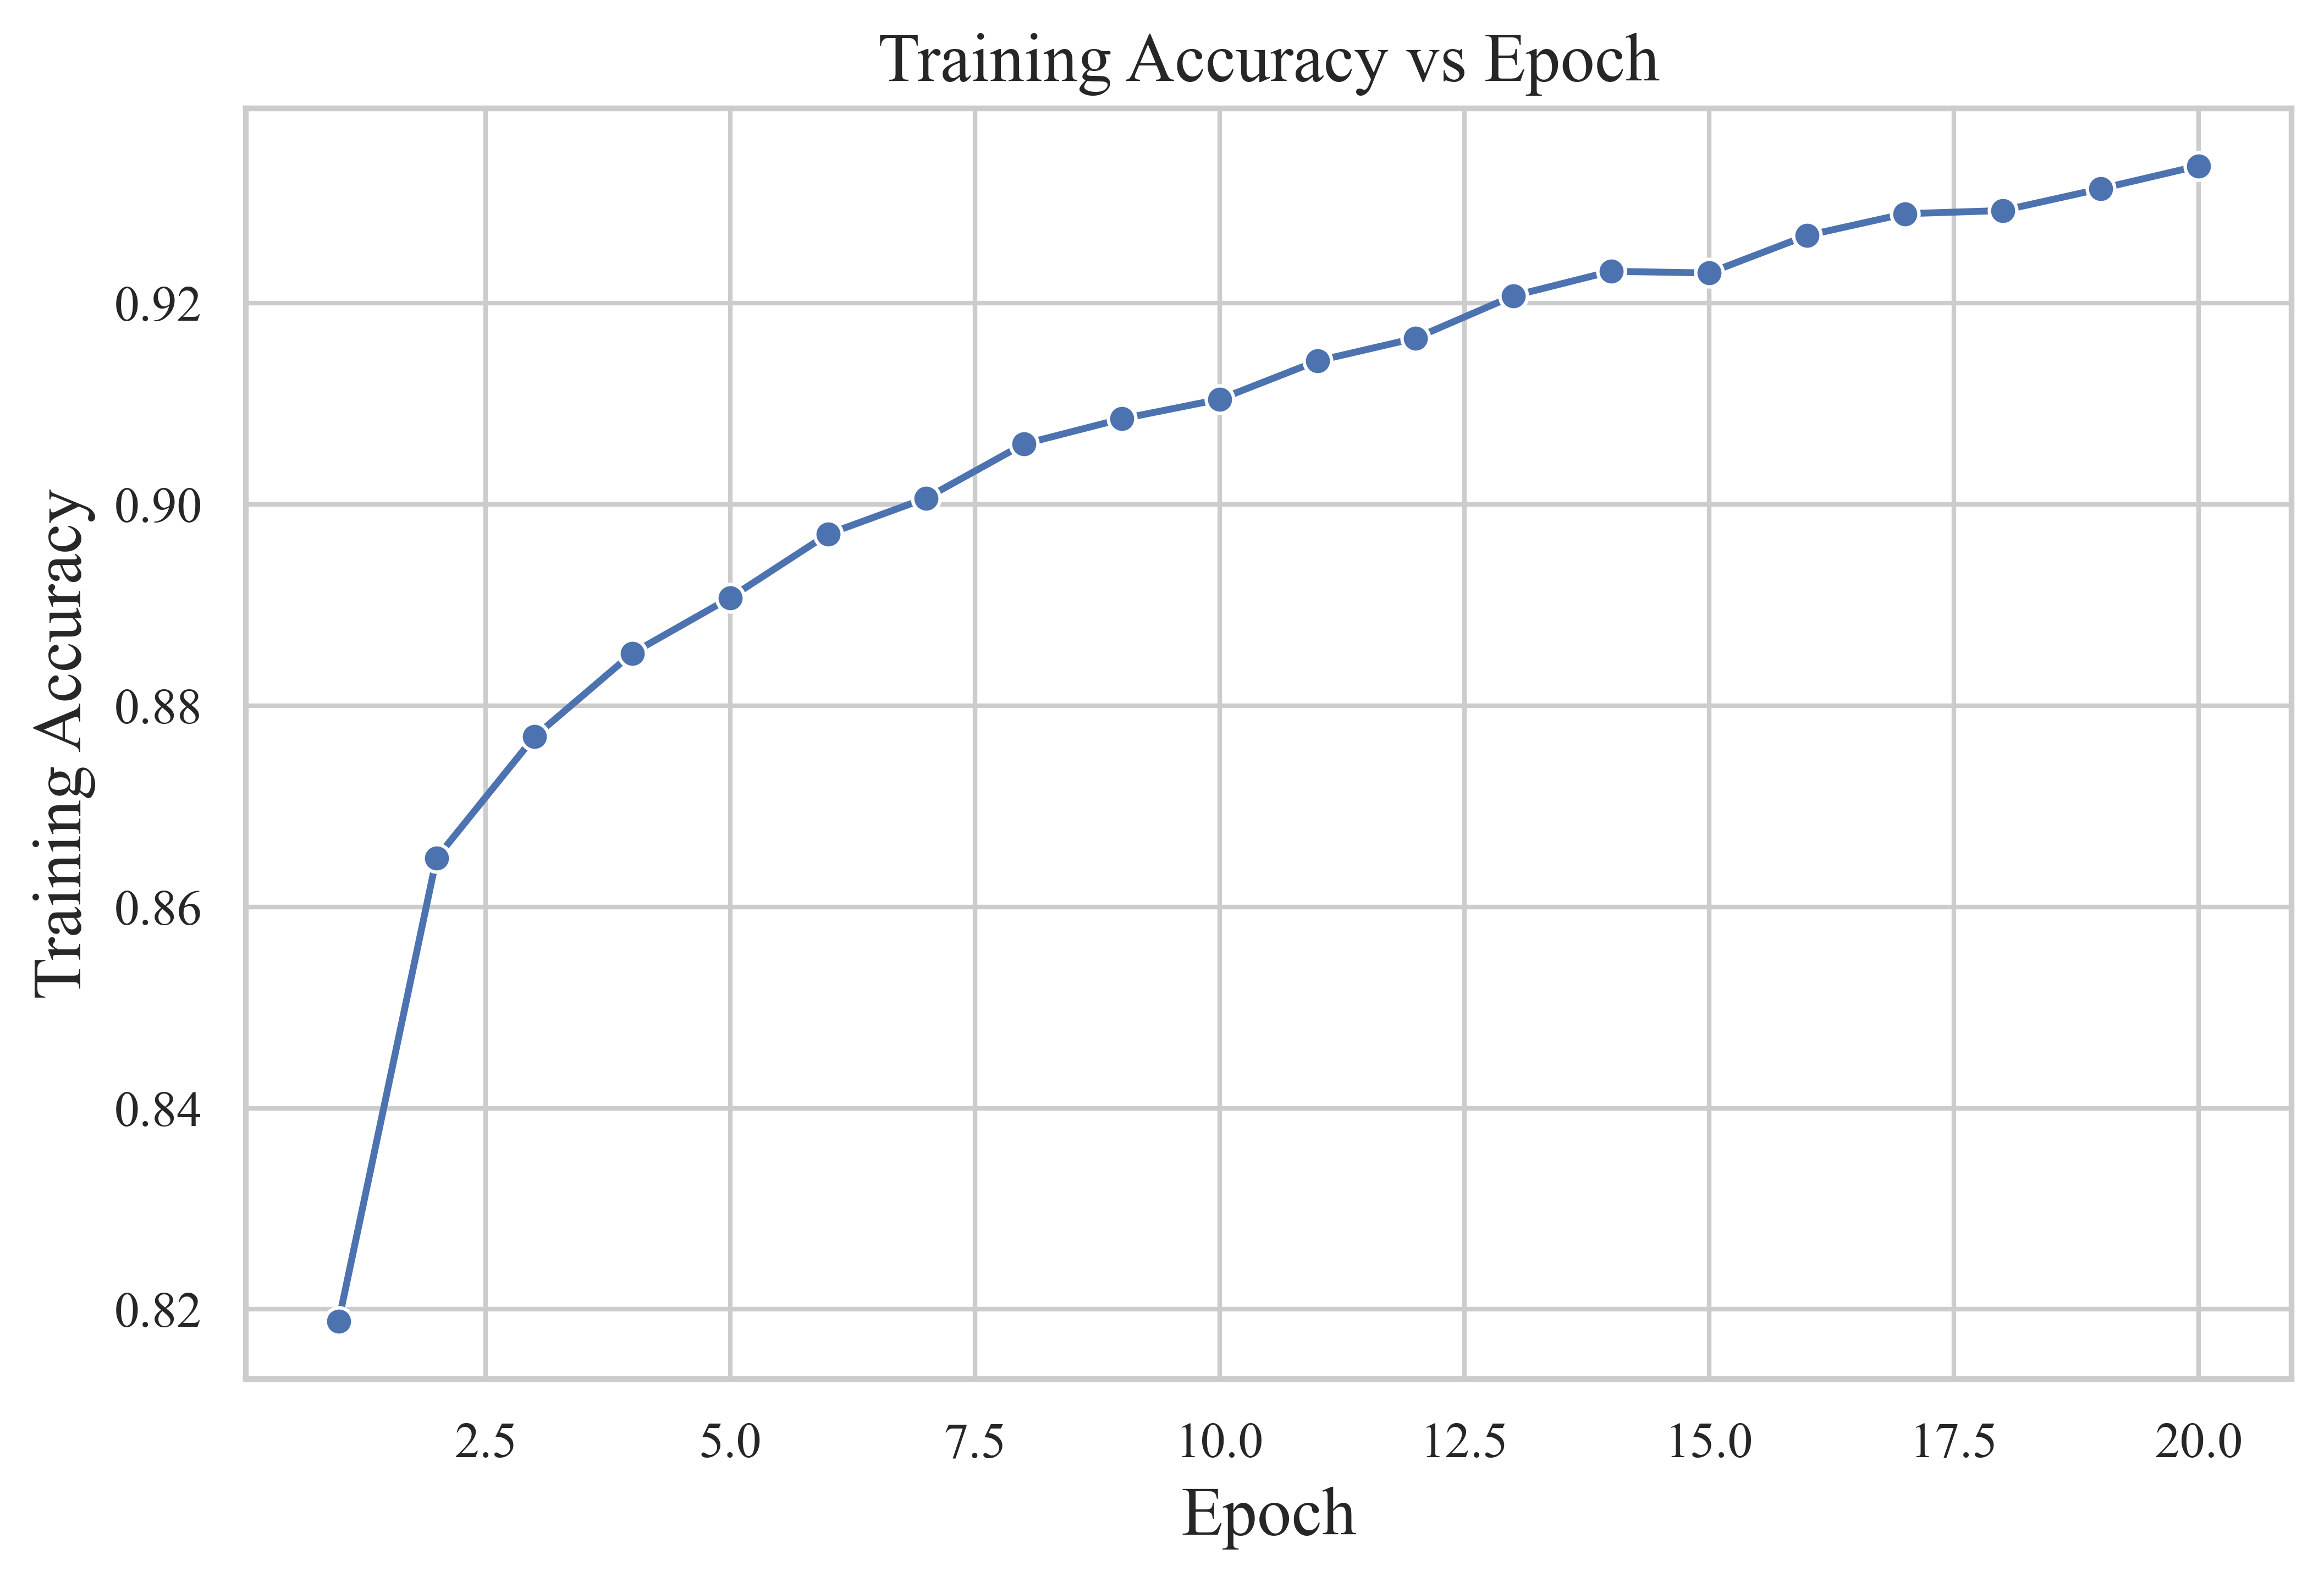

In [ ]:
# Training Accuracy vs Epoch
history_frame = pd.DataFrame(training_history.history)
history_frame['epoch'] = range(1, len(history_frame) + 1)

plt.figure(figsize=(8, 5))

train_acc_axis = sns.lineplot(
    data=history_frame,
    x='epoch',
    y='accuracy',
    marker='o',
    color='#4C72B0'
)

train_acc_axis.set_xlabel("Epoch", **label_style)
train_acc_axis.set_ylabel("Training Accuracy", **label_style)
train_acc_axis.set_title("Training Accuracy vs Epoch", **title_style)

format_axis_ticks(train_acc_axis)

plt.savefig(
    "training_accuracy_vs_epoch.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

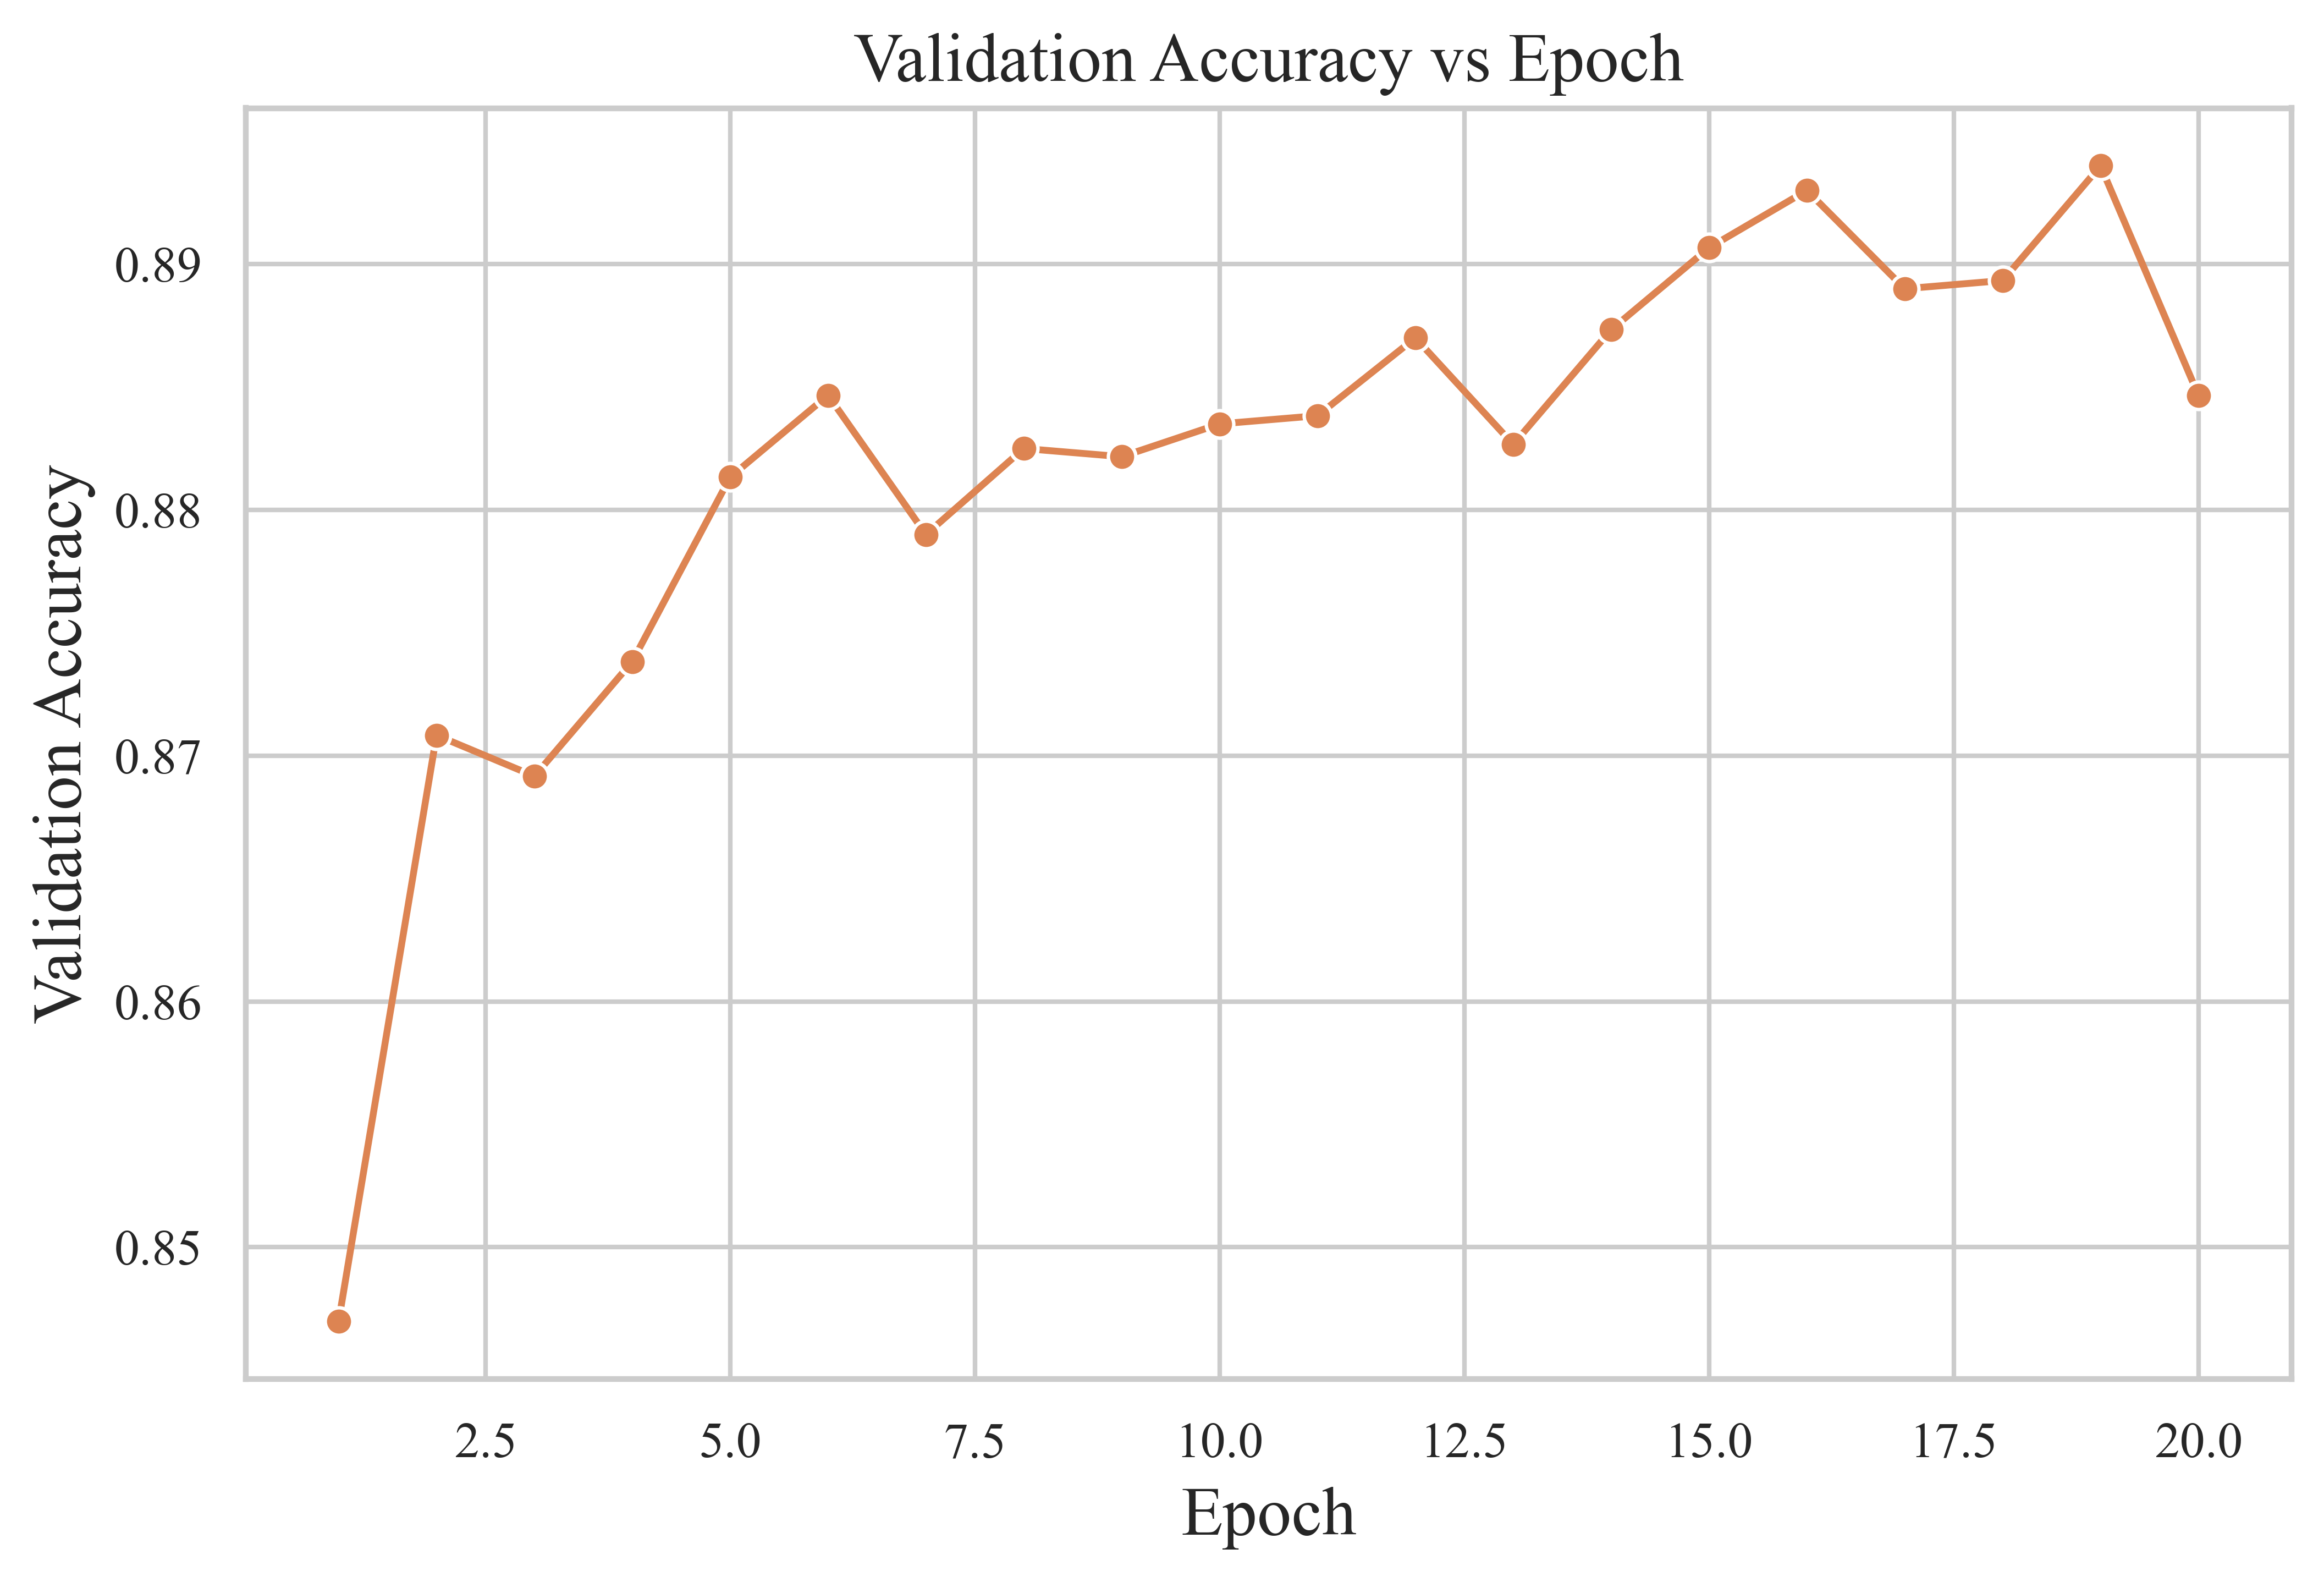

In [ ]:
# Validation Accuracy vs Epoch
plt.figure(figsize=(8, 5))

val_acc_axis = sns.lineplot(
    data=history_frame,
    x='epoch',
    y='val_accuracy',
    marker='o',
    color='#DD8452'
)

val_acc_axis.set_xlabel("Epoch", **label_style)
val_acc_axis.set_ylabel("Validation Accuracy", **label_style)
val_acc_axis.set_title("Validation Accuracy vs Epoch", **title_style)

format_axis_ticks(val_acc_axis)

plt.savefig(
    "validation_accuracy_vs_epoch.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

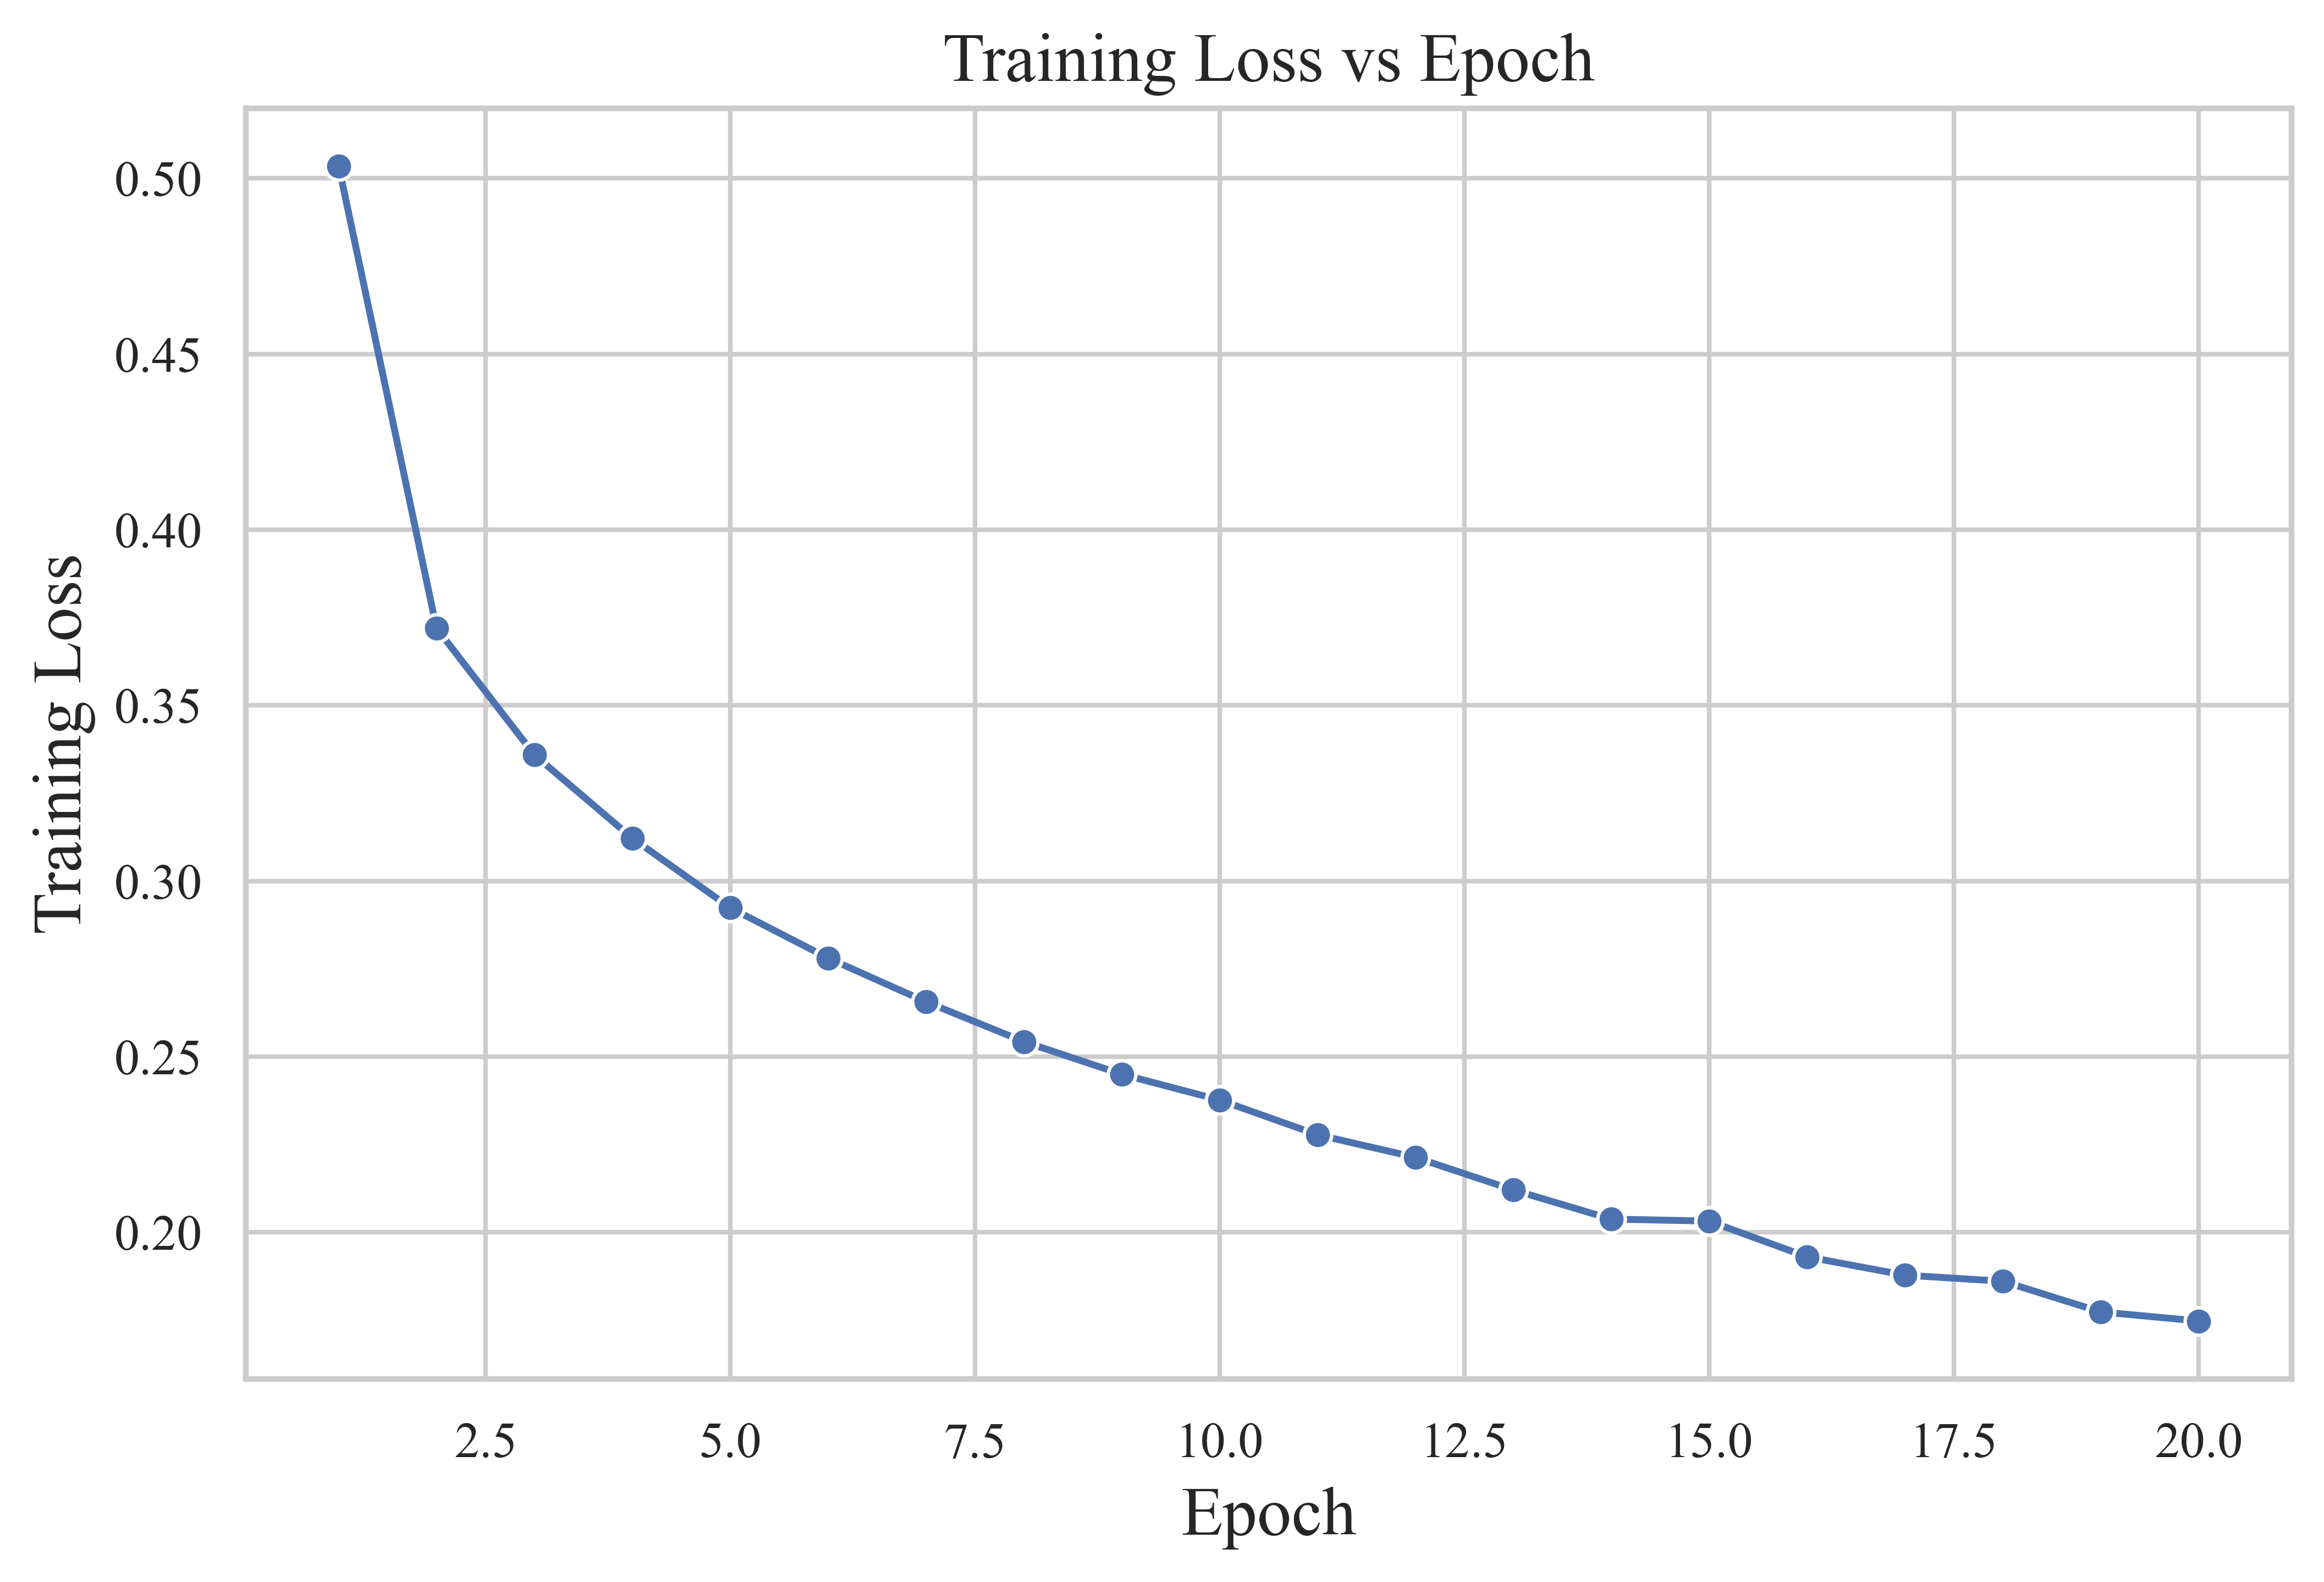

In [ ]:
# Training Loss vs Epoch
plt.figure(figsize=(8, 5))

train_loss_axis = sns.lineplot(
    data=history_frame,
    x='epoch',
    y='loss',
    marker='o',
    color='#4C72B0'
)

train_loss_axis.set_xlabel("Epoch", **label_style)
train_loss_axis.set_ylabel("Training Loss", **label_style)
train_loss_axis.set_title("Training Loss vs Epoch", **title_style)

format_axis_ticks(train_loss_axis)

plt.savefig(
    "training_loss_vs_epoch.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

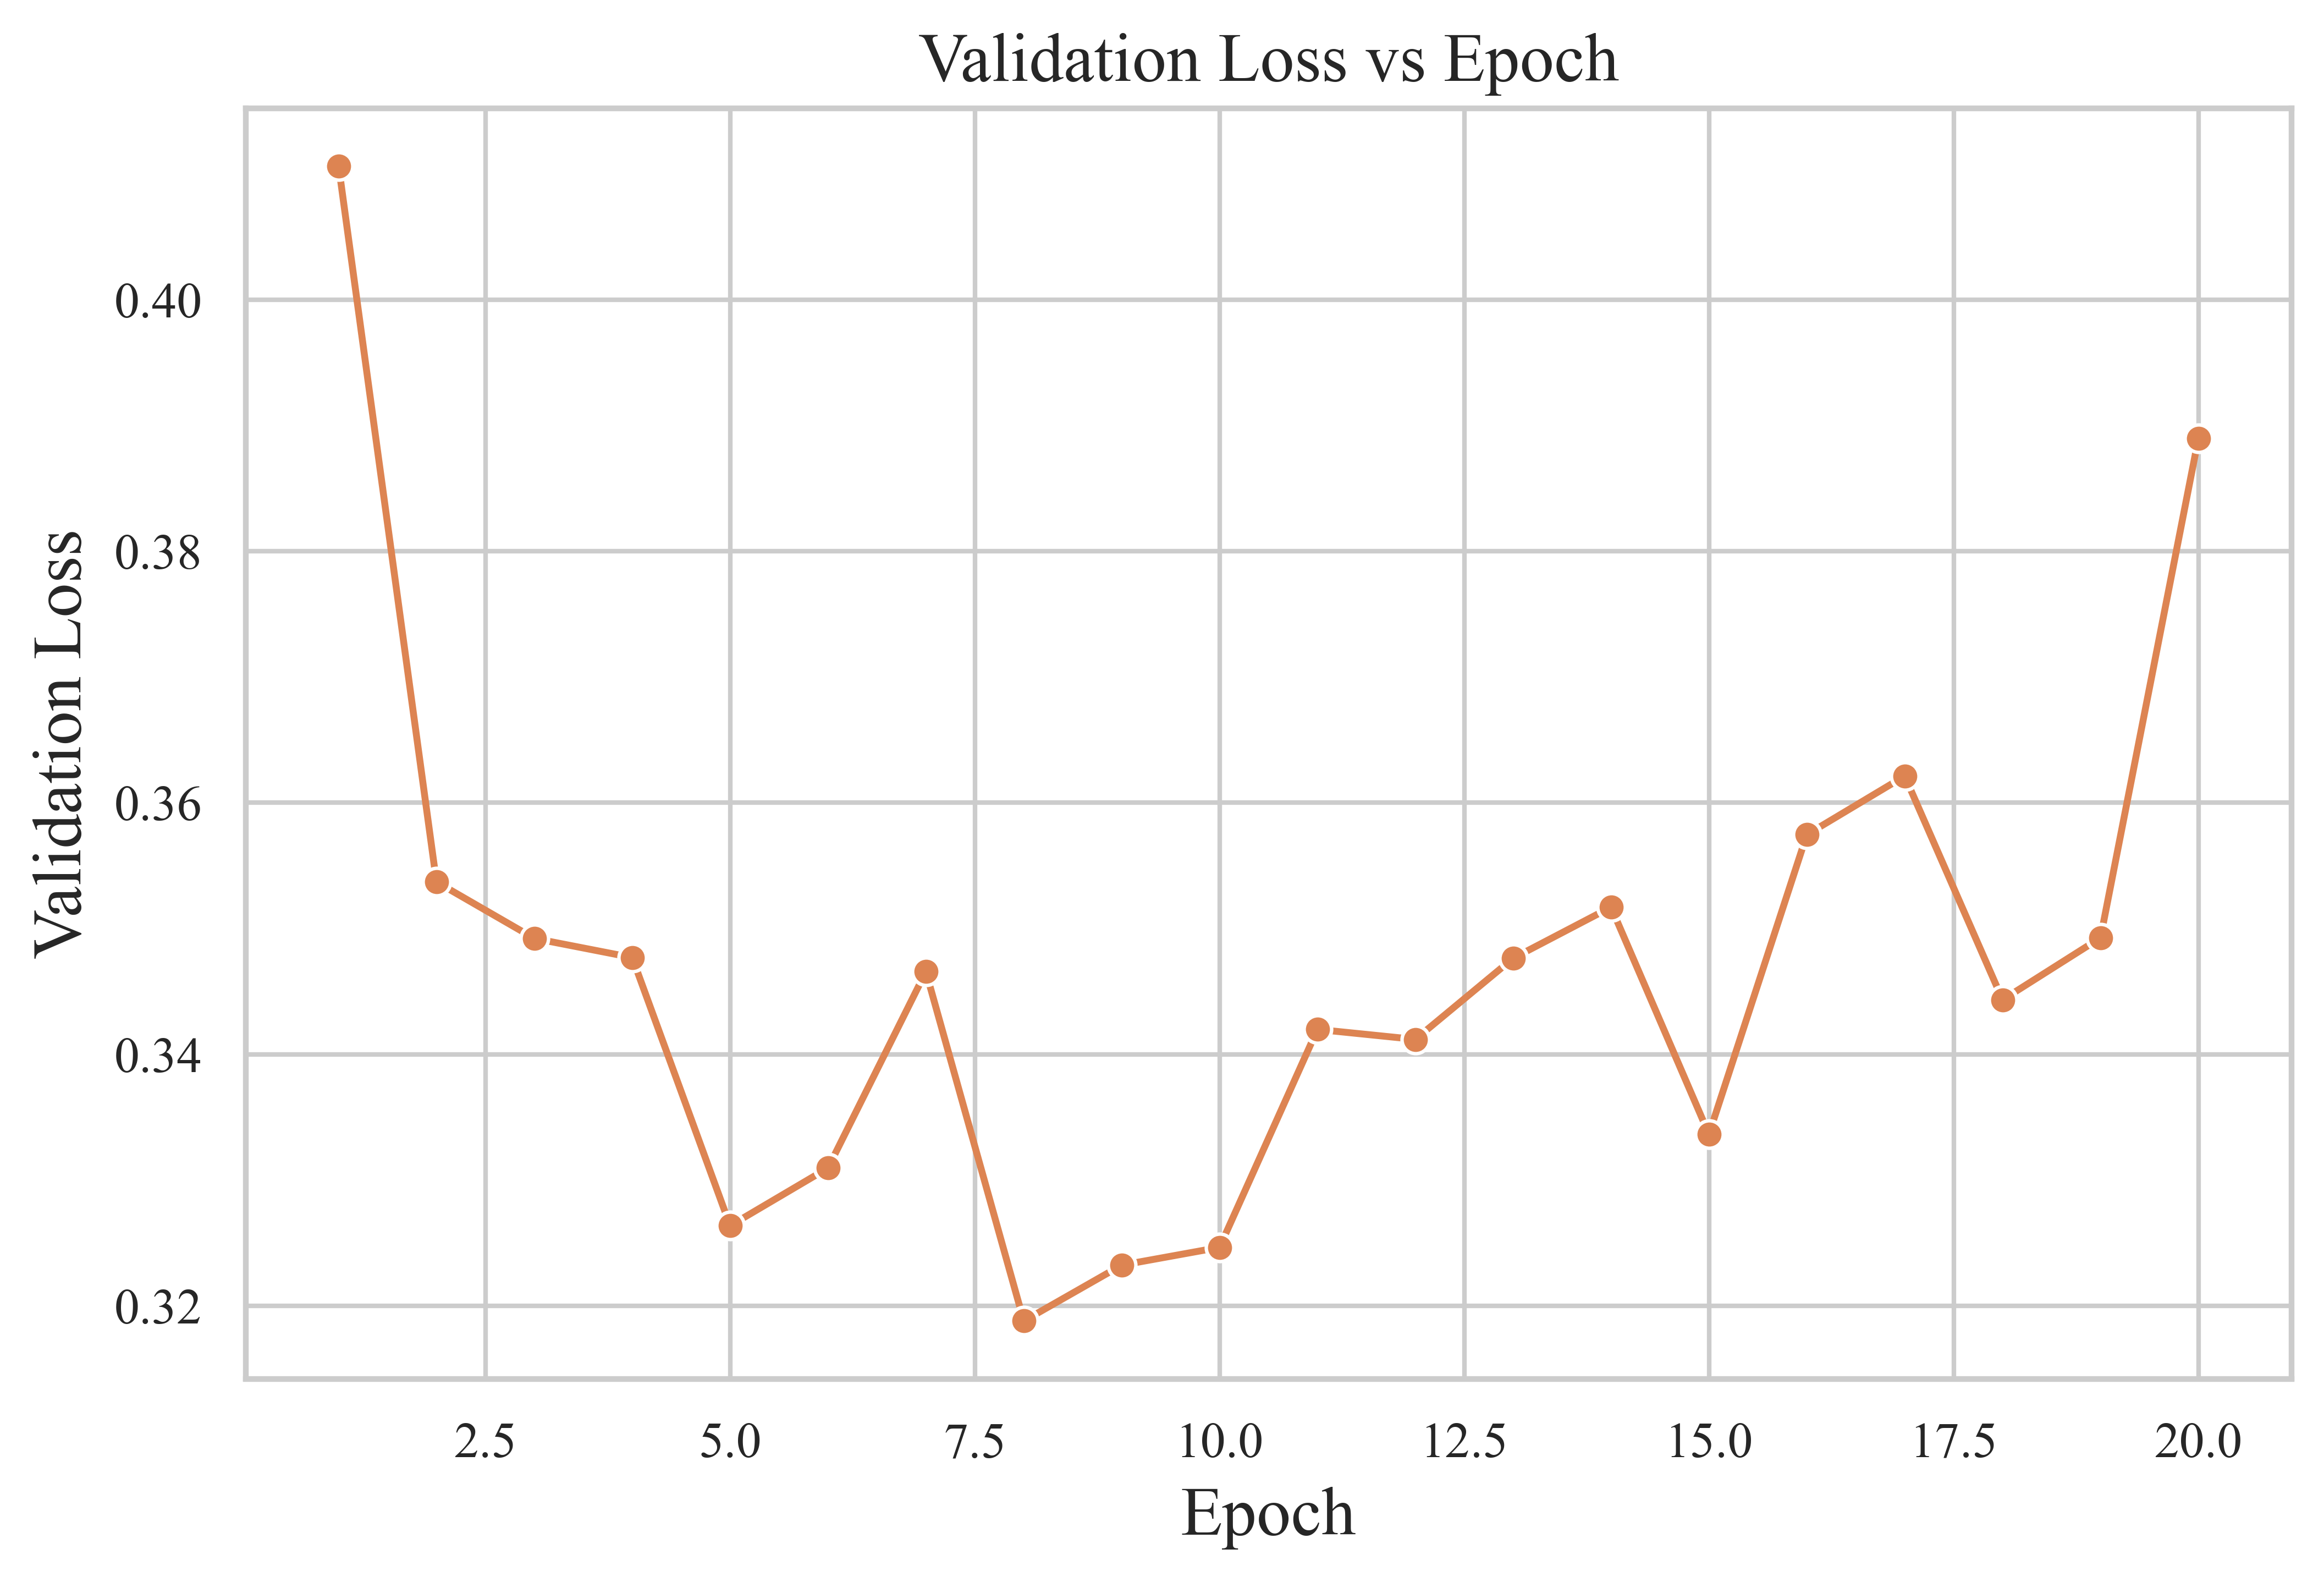

In [ ]:
# Validation Loss vs Epoch
plt.figure(figsize=(8, 5))

val_loss_axis = sns.lineplot(
    data=history_frame,
    x='epoch',
    y='val_loss',
    marker='o',
    color='#DD8452'
)

val_loss_axis.set_xlabel("Epoch", **label_style)
val_loss_axis.set_ylabel("Validation Loss", **label_style)
val_loss_axis.set_title("Validation Loss vs Epoch", **title_style)

format_axis_ticks(val_loss_axis)

plt.savefig(
    "validation_loss_vs_epoch.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# Task 5 : Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

baseline_predictions_probability = baseline_model.predict(normalized_test_images)
baseline_predicted_labels = np.argmax(baseline_predictions_probability, axis=1)

baseline_accuracy = accuracy_score(test_labels, baseline_predicted_labels)
baseline_precision = precision_score(test_labels, baseline_predicted_labels, average='macro')
baseline_recall = recall_score(test_labels, baseline_predicted_labels, average='macro')
baseline_f1 = f1_score(test_labels, baseline_predicted_labels, average='macro')

print("\nBaseline Model Performance")
print(f"Accuracy  : {baseline_accuracy:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1 Score  : {baseline_f1:.4f}")

baseline_confusion = confusion_matrix(test_labels, baseline_predicted_labels)

print("\nClassification Report")
print(classification_report(test_labels, baseline_predicted_labels, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Baseline Model Performance
Accuracy  : 0.8836
Precision : 0.8853
Recall    : 0.8836
F1 Score  : 0.8839

Classification Report
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.81      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.76      0.84      0.80      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.84      0.75      0.79      1000
      Sandal       0.94      0.98      0.96      1000
       Shirt       0.69      0.72      0.70      1000
     Sneaker       0.96      0.94      0.95      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.96      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



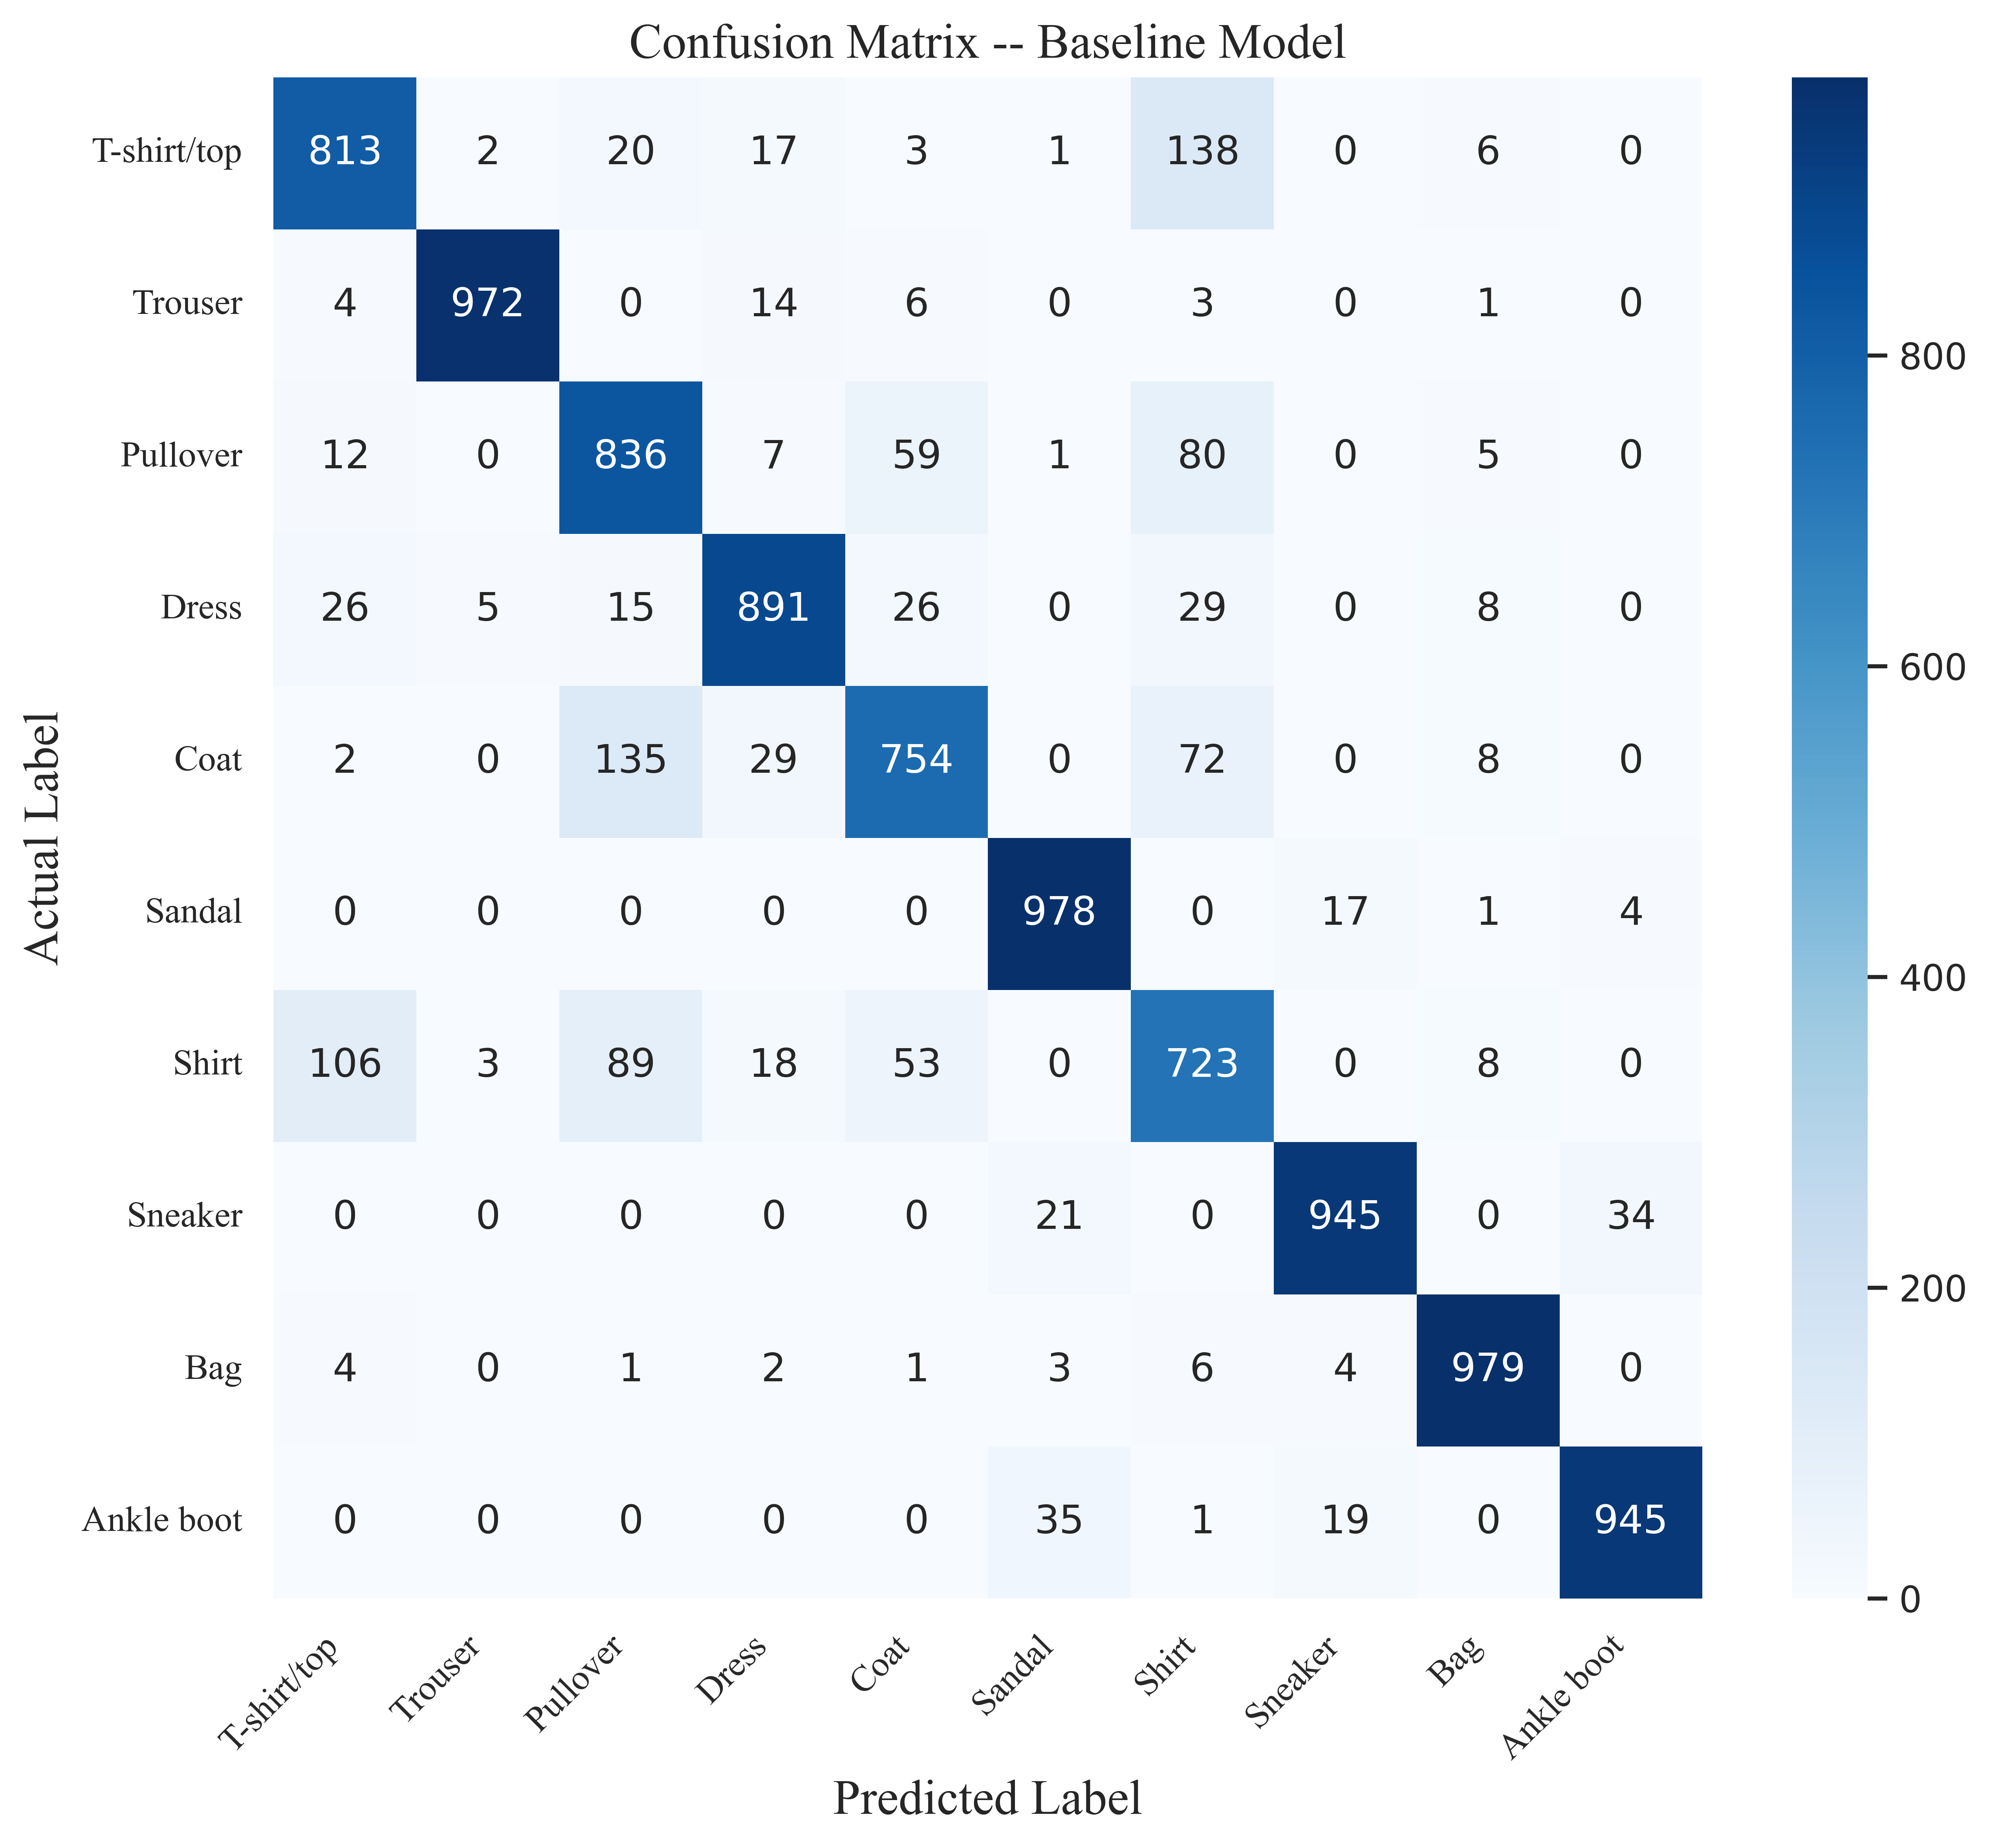

In [ ]:
# Confusion Matrix Plot -- Baseline Model
plt.figure(figsize=(9, 8))

confusion_axis = sns.heatmap(
    baseline_confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

confusion_axis.set_xlabel("Predicted Label", **label_style)
confusion_axis.set_ylabel("Actual Label", **label_style)
confusion_axis.set_title("Confusion Matrix -- Baseline Model", **title_style)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
format_axis_ticks(confusion_axis)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# Task 7 : Hyperparameter Optimization
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# --- Compatibility patch (fixes the Task 7 AttributeError) -------------
# scikeras's last release (0.13.0, Apr 2024) predates scikit-learn's
# __sklearn_tags__ API, which scikit-learn made MANDATORY starting in
# v1.6.0 (Dec 2024). On scikit-learn>=1.6 this makes
# RandomizedSearchCV(KerasClassifier(...)) crash with:
#     AttributeError: 'super' object has no attribute '__sklearn_tags__'
# This is a confirmed, still-open scikeras/scikit-learn incompatibility
# (see github.com/adriangb/scikeras/issues/332). Rather than downgrading
# scikit-learn (which fights with other packages Colab preinstalls, like
# hdbscan/umap-learn, that require scikit-learn>=1.6), we give
# KerasClassifier a working __sklearn_tags__ directly: it builds the base
# tags straight from BaseEstimator (which does NOT rely on the broken
# super() chain) and marks itself as a classifier on top of that. This is
# a no-op on scikit-learn<1.6, where the old wrapper already works fine.
import sklearn
from sklearn.base import BaseEstimator

_sklearn_version = tuple(int(p) for p in sklearn.__version__.split('.')[:2])

if _sklearn_version >= (1, 6):
    from sklearn.utils import ClassifierTags

    def _keras_classifier_sklearn_tags(self):
        tags = BaseEstimator.__sklearn_tags__(self)
        tags.estimator_type = "classifier"
        tags.classifier_tags = ClassifierTags()
        tags.target_tags.required = True
        return tags

    KerasClassifier.__sklearn_tags__ = _keras_classifier_sklearn_tags
# -------------------------------------------------------------------------

def get_mlp(meta, n_hidden=2, n_neurons=128, activation="relu", dropout=0.0):
    # `meta` is auto-injected by SciKeras and hands back n_features_in_ /
    # n_classes_ straight from the data, so the architecture always
    # matches whatever X, y are passed to .fit() -- no need to hardcode
    # 784 or 10 here.
    model = keras.Sequential()
    model.add(layers.Input(shape=(meta["n_features_in_"],)))

    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation=activation))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))

    model.add(layers.Dense(meta["n_classes_"], activation="softmax"))
    return model

searchable_classifier = KerasClassifier(
    model=get_mlp,
    loss="sparse_categorical_crossentropy",  # integer labels -> no one-hot needed
    optimizer="adam",
    metrics=["accuracy"],
    verbose=0,
)

hyperparameter_search_space = {
    "model__n_hidden":          [1, 2, 3],
    "model__n_neurons":         [32, 64, 128, 256],
    "model__activation":        ["relu", "tanh", "sigmoid"],
    "model__dropout":           [0.0, 0.2, 0.5],
    "optimizer":                ["sgd", "adam", "rmsprop"],
    "optimizer__learning_rate": [0.1, 0.01, 0.001],
    "batch_size":               [16, 32, 64, 128],
    "epochs":                   [10, 20, 30],
}

random_search = RandomizedSearchCV(
    estimator=searchable_classifier,
    param_distributions=hyperparameter_search_space,
    n_iter=15,
    cv=5,
    scoring='accuracy',
    n_jobs=1,          # keep at 1 -- parallel CV folds would fight over the same GPU
    random_state=42,
    verbose=2,
)

# NOTE: Randomized Search is run on a stratified subsample of the training
# set to keep search time reasonable; the final optimized model is then
# retrained on the FULL training set using the best hyperparameters found.
search_subsample_inputs, _, search_subsample_targets, _ = train_test_split(
    normalized_train_images,
    train_labels,
    train_size=10000,
    random_state=42,
    stratify=train_labels
)

random_search.fit(search_subsample_inputs, search_subsample_targets)

print("\nBest Hyperparameters Found")
print(random_search.best_params_)
print("Best Cross-Validation Accuracy :", random_search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__n_hidden=1, model__n_neurons=256, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  16.7s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__n_hidden=1, model__n_neurons=256, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  16.9s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__n_hidden=1, model__n_neurons=256, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  15.9s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__n_hidden=1, model__n_neurons=256, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  15.7s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__n_hidden=1, model__n_neurons=256, optimizer=rmsprop, optimizer__learning_rate=0.01; total time=  

In [10]:
# Hyperparameter Search Results Plot
search_results_frame = pd.DataFrame(random_search.cv_results_)
search_results_frame = search_results_frame.sort_values('mean_test_score', ascending=False).reset_index(drop=True)
search_results_frame['candidate'] = range(1, len(search_results_frame) + 1)

plt.figure(figsize=(10, 6))

search_results_axis = sns.barplot(
    data=search_results_frame,
    x='candidate',
    y='mean_test_score',
    color='#4C72B0'
)

search_results_axis.set_xlabel("Candidate (Ranked)", **label_style)
search_results_axis.set_ylabel("Mean CV Accuracy", **label_style)
search_results_axis.set_title("Hyperparameter Search Results", **title_style)

format_axis_ticks(search_results_axis)

plt.tight_layout()

plt.savefig(
    "hyperparameter_search_results.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

NameError: name 'random_search' is not defined

In [ ]:
# Retrain Optimized Model on Full Training Set
best_hyperparameters = random_search.best_params_

# random_search.best_params_ uses scikeras's routed parameter names
# (model__..., optimizer__...); map those back onto build_mlp_model's
# plain arguments. build_mlp_model defaults to categorical_crossentropy,
# which matches the one-hot labels used below.
optimized_model = build_mlp_model(
    hidden_layers=best_hyperparameters['model__n_hidden'],
    hidden_neurons=best_hyperparameters['model__n_neurons'],
    learning_rate=best_hyperparameters['optimizer__learning_rate'],
    optimizer_name=best_hyperparameters['optimizer'],
    activation_function=best_hyperparameters['model__activation'],
    dropout_rate=best_hyperparameters['model__dropout']
)

optimized_training_history = optimized_model.fit(
    normalized_train_images,
    one_hot_train_labels,
    validation_split=0.1,
    epochs=best_hyperparameters['epochs'],
    batch_size=best_hyperparameters['batch_size'],
    verbose=2
)

Epoch 1/30
422/422 - 5s - 12ms/step - accuracy: 0.7820 - loss: 0.6911 - val_accuracy: 0.8290 - val_loss: 0.4875
Epoch 2/30
422/422 - 1s - 3ms/step - accuracy: 0.8422 - loss: 0.4500 - val_accuracy: 0.8473 - val_loss: 0.4212
Epoch 3/30
422/422 - 1s - 3ms/step - accuracy: 0.8572 - loss: 0.4046 - val_accuracy: 0.8562 - val_loss: 0.3956
Epoch 4/30
422/422 - 1s - 3ms/step - accuracy: 0.8661 - loss: 0.3792 - val_accuracy: 0.8588 - val_loss: 0.3832
Epoch 5/30
422/422 - 1s - 3ms/step - accuracy: 0.8709 - loss: 0.3600 - val_accuracy: 0.8650 - val_loss: 0.3625
Epoch 6/30
422/422 - 1s - 3ms/step - accuracy: 0.8762 - loss: 0.3458 - val_accuracy: 0.8598 - val_loss: 0.3751
Epoch 7/30
422/422 - 1s - 3ms/step - accuracy: 0.8800 - loss: 0.3336 - val_accuracy: 0.8730 - val_loss: 0.3534
Epoch 8/30
422/422 - 1s - 3ms/step - accuracy: 0.8861 - loss: 0.3209 - val_accuracy: 0.8678 - val_loss: 0.3470
Epoch 9/30
422/422 - 2s - 4ms/step - accuracy: 0.8883 - loss: 0.3106 - val_accuracy: 0.8767 - val_loss: 0.3296


In [ ]:
# Evaluate Optimized Model
optimized_predictions_probability = optimized_model.predict(normalized_test_images)
optimized_predicted_labels = np.argmax(optimized_predictions_probability, axis=1)

optimized_accuracy = accuracy_score(test_labels, optimized_predicted_labels)
optimized_precision = precision_score(test_labels, optimized_predicted_labels, average='macro')
optimized_recall = recall_score(test_labels, optimized_predicted_labels, average='macro')
optimized_f1 = f1_score(test_labels, optimized_predicted_labels, average='macro')

print("\nOptimized Model Performance")
print(f"Accuracy  : {optimized_accuracy:.4f}")
print(f"Precision : {optimized_precision:.4f}")
print(f"Recall    : {optimized_recall:.4f}")
print(f"F1 Score  : {optimized_f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Optimized Model Performance
Accuracy  : 0.8871
Precision : 0.8871
Recall    : 0.8871
F1 Score  : 0.8868


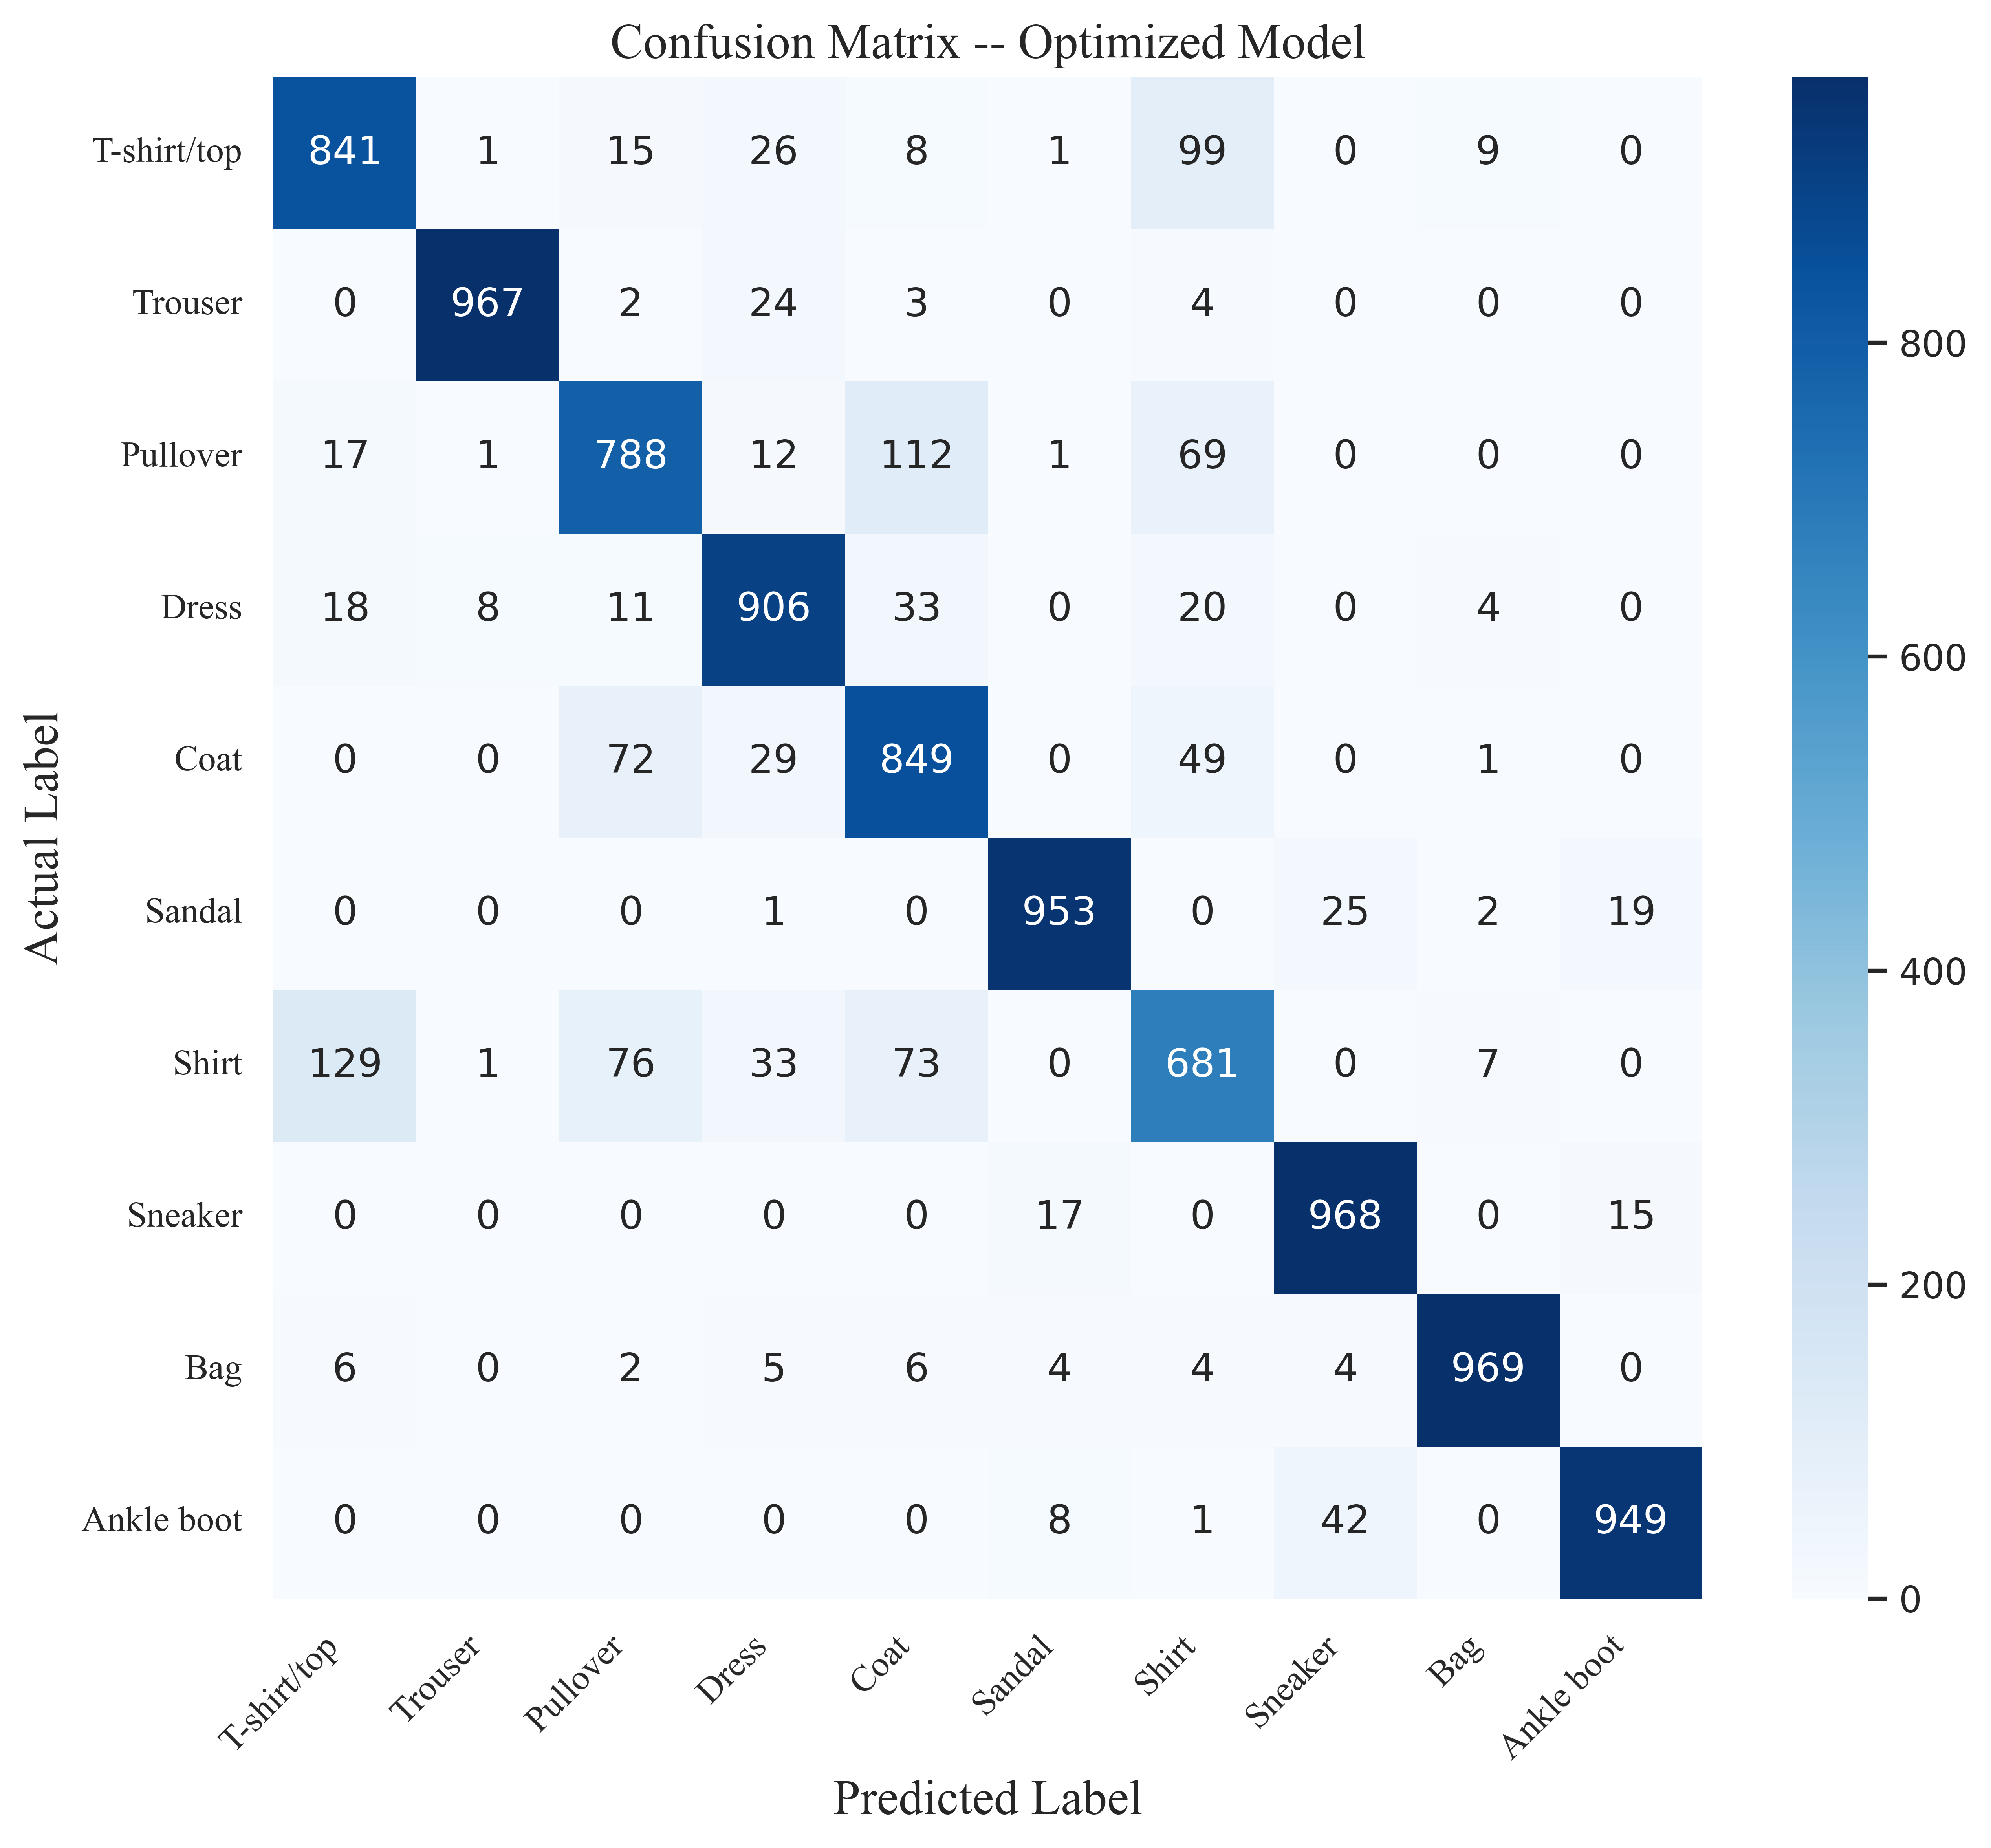

In [ ]:
# Confusion Matrix Plot -- Optimized Model (bonus, for direct comparison
# against the baseline confusion matrix above)
optimized_confusion = confusion_matrix(test_labels, optimized_predicted_labels)

plt.figure(figsize=(9, 8))

optimized_confusion_axis = sns.heatmap(
    optimized_confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

optimized_confusion_axis.set_xlabel("Predicted Label", **label_style)
optimized_confusion_axis.set_ylabel("Actual Label", **label_style)
optimized_confusion_axis.set_title("Confusion Matrix -- Optimized Model", **title_style)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
format_axis_ticks(optimized_confusion_axis)

plt.tight_layout()

plt.savefig(
    "confusion_matrix_optimized.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# Baseline vs Optimized Comparison Table
comparison_frame = pd.DataFrame({
    "Model": ["Baseline", "Optimized"],
    "Accuracy": [baseline_accuracy, optimized_accuracy],
    "Precision": [baseline_precision, optimized_precision],
    "Recall": [baseline_recall, optimized_recall],
    "F1 Score": [baseline_f1, optimized_f1]
})

print("\nBaseline vs Optimized Comparison")
print(comparison_frame)


Baseline vs Optimized Comparison
       Model  Accuracy  Precision  Recall  F1 Score
0   Baseline    0.8836   0.885317  0.8836  0.883938
1  Optimized    0.8871   0.887108  0.8871  0.886754


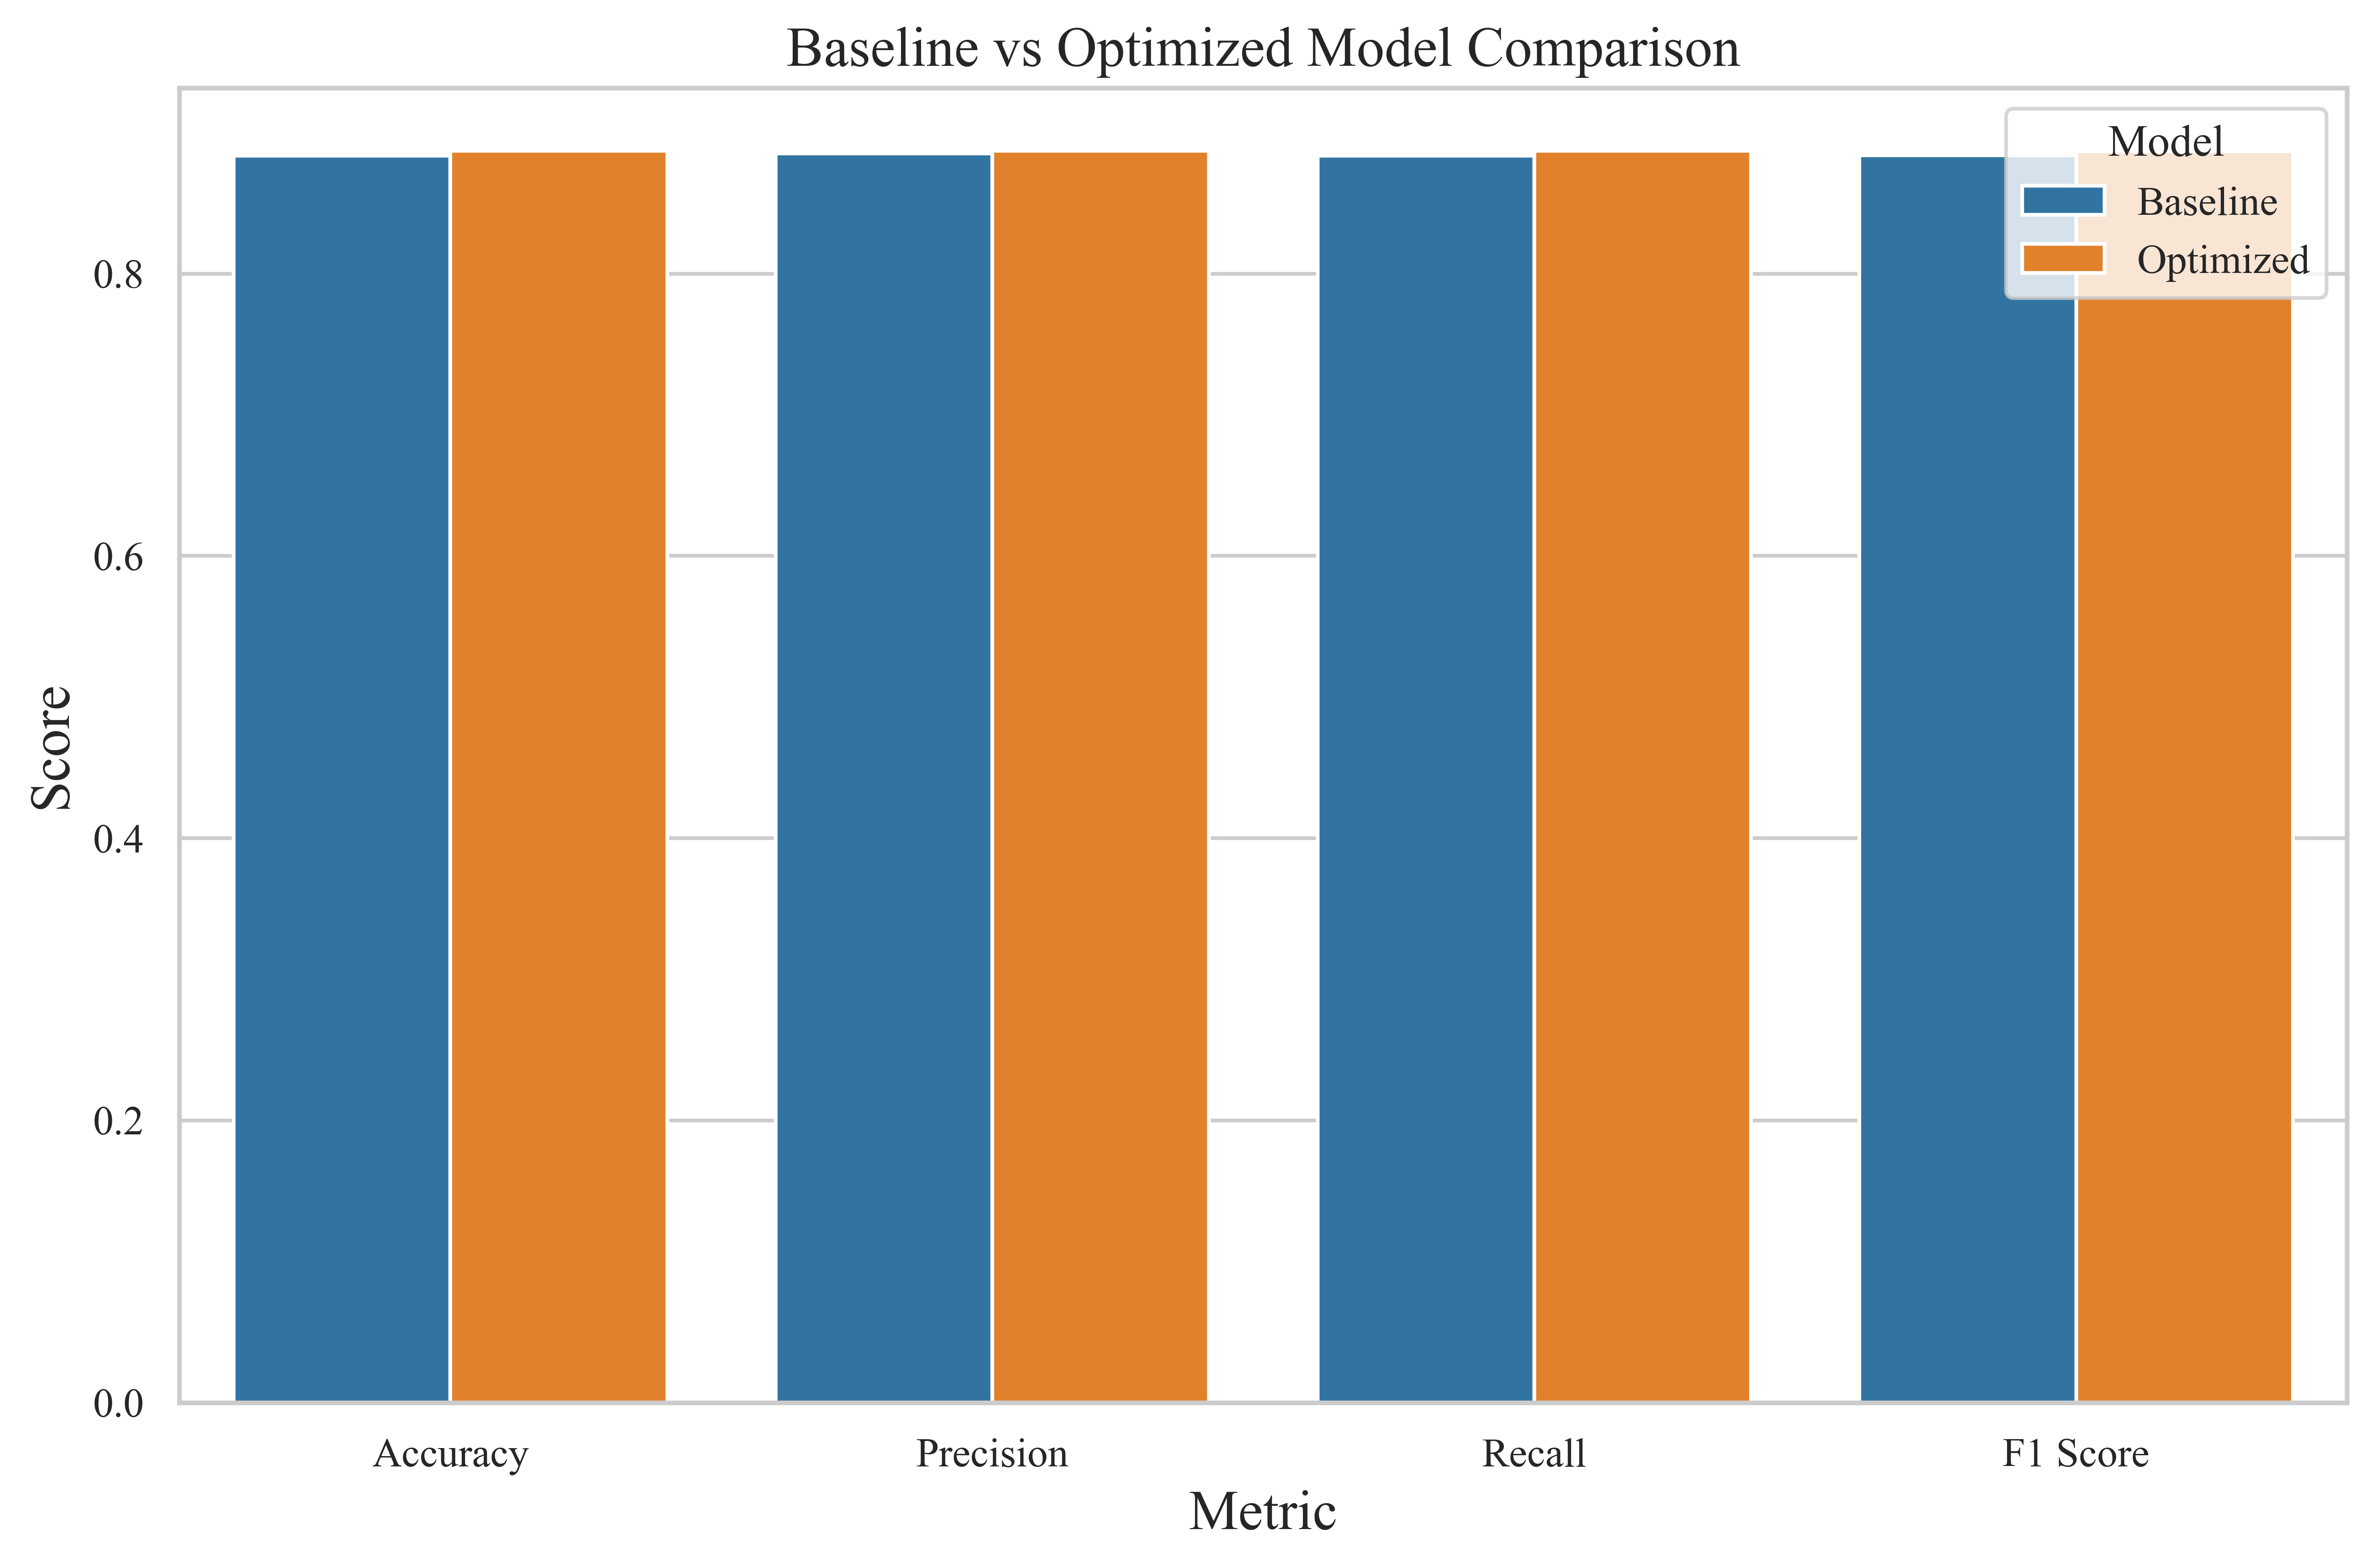

In [ ]:
# Best Model Accuracy Comparison Plot
comparison_melted = comparison_frame.melt(
    id_vars='Model',
    var_name='metric',
    value_name='score'
)

plt.figure(figsize=(9, 6))

comparison_axis = sns.barplot(
    data=comparison_melted,
    x='metric',
    y='score',
    hue='Model'
)

comparison_axis.set_xlabel("Metric", **label_style)
comparison_axis.set_ylabel("Score", **label_style)
comparison_axis.set_title("Baseline vs Optimized Model Comparison", **title_style)

format_axis_ticks(comparison_axis)
format_legend_text(comparison_axis.get_legend())

plt.tight_layout()

plt.savefig(
    "best_model_comparison.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# ============================================================
# Bonus Task : Perceptron Learning Algorithm for the XOR Gate
# (Self-contained -- does not depend on any earlier cell in this
#  notebook. Safe to run on its own, in a fresh runtime, without
#  running Tasks 1-7 first.)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Local plot styling (kept separate from the main notebook's styling
# cell so this section never depends on it having been run first).
xor_label_style = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Times New Roman'}
xor_title_style = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Times New Roman'}

def xor_format_axis_ticks(current_axis):
    for tick_label in (current_axis.get_xticklabels() + current_axis.get_yticklabels()):
        tick_label.set_fontweight('bold')
        tick_label.set_fontname('Times New Roman')

def xor_format_legend_text(current_legend):
    if current_legend is not None:
        for legend_entry in current_legend.get_texts():
            legend_entry.set_fontweight('bold')
            legend_entry.set_fontname('Times New Roman')
        legend_title = current_legend.get_title()
        legend_title.set_fontweight('bold')
        legend_title.set_fontname('Times New Roman')

# XOR is NOT linearly separable, so a single-layer perceptron (the same
# kind of model used in Lab 1) can never fully converge on it. This task
# implements that perceptron from scratch, logs the weights after every
# single update, and plots the decision boundary at each of those updates
# to show directly why the algorithm keeps failing.

xor_inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
xor_targets = np.array([0, 1, 1, 0])  # XOR truth table

def step_activation(z):
    return np.where(z >= 0, 1, 0)

xor_weights = np.zeros(2)
xor_bias = 0.0
xor_learning_rate = 0.1
xor_max_epochs = 5

# weight_history[0] is the state BEFORE any training (Update 0)
weight_history = [(xor_weights.copy(), xor_bias)]
misclassified_per_epoch = []

update_count = 0
print(f"Initial weights: {xor_weights}, bias: {xor_bias:.4f}\n")

for epoch in range(1, xor_max_epochs + 1):
    epoch_errors = 0

    for sample_input, target in zip(xor_inputs, xor_targets):
        weighted_sum = np.dot(sample_input, xor_weights) + xor_bias
        prediction = step_activation(weighted_sum)
        error = target - prediction

        if error != 0:
            xor_weights = xor_weights + xor_learning_rate * error * sample_input
            xor_bias = xor_bias + xor_learning_rate * error
            update_count += 1
            epoch_errors += 1

            weight_history.append((xor_weights.copy(), xor_bias))

            print(
                f"Update {update_count:2d} (Epoch {epoch}) | "
                f"Input: {sample_input} | Target: {target} | Predicted: {int(prediction)} | "
                f"Weights: [{xor_weights[0]:.4f}, {xor_weights[1]:.4f}] | Bias: {xor_bias:.4f}"
            )

    misclassified_per_epoch.append(epoch_errors)

print(f"\nTotal weight updates over {xor_max_epochs} epochs: {update_count}")
print(f"Misclassifications per epoch: {misclassified_per_epoch}")

In [ ]:
# XOR Decision Boundary After Each Weight Update
xx_grid, yy_grid = np.meshgrid(
    np.linspace(-0.5, 1.5, 200),
    np.linspace(-0.5, 1.5, 200)
)
grid_points = np.c_[xx_grid.ravel(), yy_grid.ravel()]

num_snapshots = len(weight_history)
grid_cols = 5
grid_rows = int(np.ceil(num_snapshots / grid_cols))

boundary_figure, boundary_axes = plt.subplots(
    grid_rows, grid_cols,
    figsize=(grid_cols * 2.6, grid_rows * 2.6)
)
boundary_axes = np.array(boundary_axes).reshape(-1)

for snapshot_index, (snapshot_weights, snapshot_bias) in enumerate(weight_history):
    current_axis = boundary_axes[snapshot_index]

    grid_predictions = step_activation(
        grid_points @ snapshot_weights + snapshot_bias
    ).reshape(xx_grid.shape)

    current_axis.contourf(
        xx_grid, yy_grid, grid_predictions,
        levels=[-0.5, 0.5, 1.5],
        colors=['#d1d1e0', '#f4b8b8'],
        alpha=0.85
    )

    current_axis.scatter(
        xor_inputs[:, 0], xor_inputs[:, 1],
        c=['#4C72B0' if t == 0 else '#DD8452' for t in xor_targets],
        edgecolor='black', s=55, zorder=3
    )

    current_axis.set_title(
        f"Update {snapshot_index}",
        fontsize=9, fontweight='bold', fontname='Times New Roman'
    )
    current_axis.set_xlim(-0.5, 1.5)
    current_axis.set_ylim(-0.5, 1.5)
    current_axis.set_xticks([])
    current_axis.set_yticks([])

for unused_axis in boundary_axes[num_snapshots:]:
    unused_axis.axis('off')

boundary_figure.suptitle(
    "XOR Decision Boundary After Each Weight Update",
    fontsize=15, fontweight='bold', fontname='Times New Roman'
)

plt.tight_layout()

plt.savefig(
    "xor_decision_boundary_evolution.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# XOR Training Error vs Epoch -- direct evidence of non-convergence
xor_history_frame = pd.DataFrame({
    'epoch': range(1, xor_max_epochs + 1),
    'misclassified': misclassified_per_epoch
})

plt.figure(figsize=(8, 5))

xor_error_axis = sns.lineplot(
    data=xor_history_frame,
    x='epoch',
    y='misclassified',
    marker='o',
    color='#C44E52'
)

xor_error_axis.set_xlabel("Epoch", **xor_label_style)
xor_error_axis.set_ylabel("Misclassified Samples (out of 4)", **xor_label_style)
xor_error_axis.set_title("Perceptron Trained on XOR -- Non-Convergence", **xor_title_style)
xor_error_axis.set_ylim(-0.5, 4.5)

xor_format_axis_ticks(xor_error_axis)

plt.savefig(
    "xor_training_error.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# XOR Weight and Bias Evolution Over Updates
weight_values = np.array([w for w, b in weight_history])
bias_values = np.array([b for w, b in weight_history])

xor_weight_frame = pd.DataFrame({
    'update': range(len(weight_history)),
    'Weight 1': weight_values[:, 0],
    'Weight 2': weight_values[:, 1],
    'Bias': bias_values
})

xor_weight_melted = xor_weight_frame.melt(
    id_vars='update', var_name='parameter', value_name='value'
)

plt.figure(figsize=(8, 5))

xor_weight_axis = sns.lineplot(
    data=xor_weight_melted,
    x='update', y='value', hue='parameter',
    marker='o'
)

xor_weight_axis.set_xlabel("Weight Update Number", **xor_label_style)
xor_weight_axis.set_ylabel("Value", **xor_label_style)
xor_weight_axis.set_title("XOR Weight and Bias Evolution", **xor_title_style)

xor_format_axis_ticks(xor_weight_axis)
xor_format_legend_text(xor_weight_axis.get_legend())

plt.savefig(
    "xor_weight_evolution.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# Analysis : Why the Perceptron Never Converges on XOR
print("Analysis")
print("-" * 60)
print(f"Misclassifications per epoch across {xor_max_epochs} epochs: {misclassified_per_epoch}")
print(f"Minimum misclassifications reached: {min(misclassified_per_epoch)} out of 4\n")

print(
    "The error count never reaches zero -- it keeps oscillating between\n"
    "misclassified samples every epoch, no matter how long training\n"
    "continues.\n\n"
    "The pattern responsible for this is that XOR is NOT LINEARLY SEPARABLE:\n"
    "the two positive points (0,1) and (1,0) and the two negative points\n"
    "(0,0) and (1,1) cannot be separated by any single straight line in the\n"
    "2D input space. Every weight update in the decision-boundary grid\n"
    "above rotates or shifts the line to fix whichever point it just got\n"
    "wrong -- but doing so always breaks a different point that was\n"
    "previously correct, since no orientation of a straight line can keep\n"
    "all four points on their correct sides simultaneously. This is exactly\n"
    "why solving XOR requires a hidden layer (an MLP, as used earlier in\n"
    "this notebook), which combines multiple linear boundaries into a\n"
    "non-linear decision region instead of being restricted to a single\n"
    "straight line."
)

In [ ]:
# Download All Generated EPS Plots
import glob
import zipfile
from google.colab import files

eps_files = sorted(glob.glob("*.eps"))
print(f"Found {len(eps_files)} EPS files:")
for f in eps_files:
    print(" -", f)

with zipfile.ZipFile("lab2_eps_plots.zip", "w") as zf:
    for f in eps_files:
        zf.write(f)

files.download("lab2_eps_plots.zip")

Found 10 EPS files:
 - best_model_comparison.eps
 - class_distribution.eps
 - confusion_matrix.eps
 - confusion_matrix_optimized.eps
 - hyperparameter_search_results.eps
 - sample_images.eps
 - training_accuracy_vs_epoch.eps
 - training_loss_vs_epoch.eps
 - validation_accuracy_vs_epoch.eps
 - validation_loss_vs_epoch.eps


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>